In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import numpy as np

In [24]:
import os

# Root path to the dataset
root_path = "/kaggle/input/cifar-10"

# Walk through the directory and print everything
for dirpath, dirnames, filenames in os.walk(root_path):
    print(f"Directory: {dirpath}")
    for dirname in dirnames:
        print(f"  Sub-directory: {dirname}")
    for filename in filenames:
        print(f"  File: {filename}")

Directory: /kaggle/input/cifar-10
  File: trainLabels.csv
  File: sampleSubmission.csv
  File: test.7z
  File: train.7z


In [2]:
!pip install py7zr

import py7zr
import os

# Create folders to extract
os.makedirs("train_images", exist_ok=True)
os.makedirs("test_images", exist_ok=True)

# Extract train.7z
with py7zr.SevenZipFile("/kaggle/input/cifar-10/train.7z", mode='r') as z:
    z.extractall(path="train_images")

# Extract test.7z
with py7zr.SevenZipFile("/kaggle/input/cifar-10/test.7z", mode='r') as z:
    z.extractall(path="test_images")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 22.8 MB/s eta 0:00:00


In [3]:
for dirpath, dirnames, filenames in os.walk("train_images"):
    print(f"Directory: {dirpath}")
    for filename in filenames[:5]:  # print only first 5 to avoid clutter
        print(f"  File: {filename}")

Directory: train_images
Directory: train_images/train
  File: 16337.png
  File: 8196.png
  File: 8424.png
  File: 10060.png
  File: 29938.png


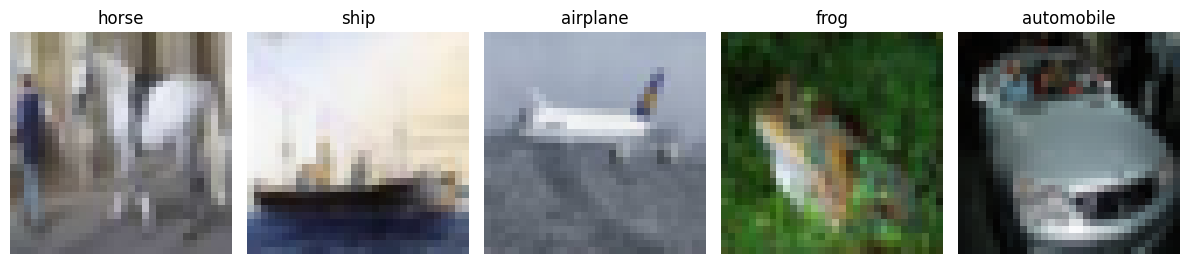

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Load labels
labels_df = pd.read_csv("/kaggle/input/cifar-10/trainLabels.csv")

# Full path to extracted images
image_dir = "train_images/train"

# Preview 5 images
sample_images = labels_df.sample(5, random_state=42)  # randomly pick 5 images

plt.figure(figsize=(12, 4))
for i, row in enumerate(sample_images.itertuples()):
    image_path = os.path.join(image_dir, f"{row.id}.png")
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import os
import shutil

# Load labels
labels_df = pd.read_csv("/kaggle/input/cifar-10/trainLabels.csv")
filtered_df = labels_df[labels_df['label'].isin(['cat', 'dog'])]

# Sample 5,000 each
cat_df = filtered_df[filtered_df['label'] == 'cat'].sample(5000, random_state=42)
dog_df = filtered_df[filtered_df['label'] == 'dog'].sample(5000, random_state=42)

# Combine and shuffle
final_df = pd.concat([cat_df, dog_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# Split: 80% train, 20% test
train_df = final_df[:8000]
test_df = final_df[8000:]

# Create directories
for split in ['train', 'test']:
    for label in ['cat', 'dog']:
        os.makedirs(f'dataset/{split}/{label}', exist_ok=True)

# Copy files to folders
def copy_images(df, split):
    for row in df.itertuples():
        src = f"train_images/train/{row.id}.png"
        dst = f"dataset/{split}/{row.label}/{row.id}.png"
        shutil.copy(src, dst)

copy_images(train_df, 'train')
copy_images(test_df, 'test')


In [6]:
print("Train set:")
print("  Cats:", len(os.listdir('dataset/train/cat')))
print("  Dogs:", len(os.listdir('dataset/train/dog')))
print("Test set:")
print("  Cats:", len(os.listdir('dataset/test/cat')))
print("  Dogs:", len(os.listdir('dataset/test/dog')))


Train set:
  Cats: 4020
  Dogs: 3980
Test set:
  Cats: 980
  Dogs: 1020


Epoch [1/100]  D_loss: 0.6941  G_loss: 10.7414  Sim_Score: 0.0005
Epoch [2/100]  D_loss: 0.6615  G_loss: 12.7116  Sim_Score: 0.0003
Epoch [3/100]  D_loss: 0.6230  G_loss: 13.8972  Sim_Score: 0.0001
Epoch [4/100]  D_loss: 0.5776  G_loss: 15.0788  Sim_Score: 0.0001
Epoch [5/100]  D_loss: 0.5266  G_loss: 14.7602  Sim_Score: 0.0001
Epoch [6/100]  D_loss: 0.4728  G_loss: 17.0898  Sim_Score: 0.0000
Epoch [7/100]  D_loss: 0.4191  G_loss: 16.6234  Sim_Score: 0.0000
Epoch [8/100]  D_loss: 0.3675  G_loss: 18.0777  Sim_Score: 0.0000
Epoch [9/100]  D_loss: 0.3197  G_loss: 17.8589  Sim_Score: 0.0000
Epoch [10/100]  D_loss: 0.2766  G_loss: 19.0858  Sim_Score: 0.0000


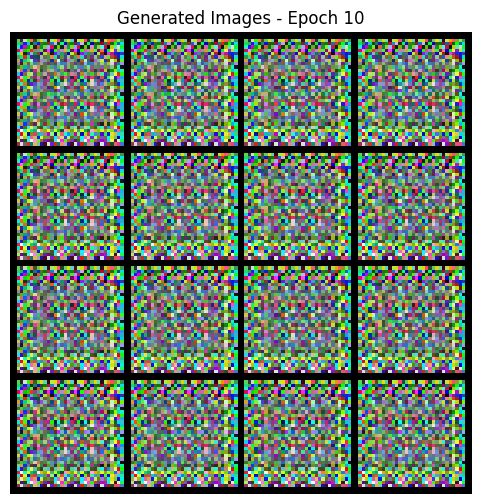

Epoch [11/100]  D_loss: 0.2385  G_loss: 19.7664  Sim_Score: 0.0000
Epoch [12/100]  D_loss: 0.2054  G_loss: 19.8551  Sim_Score: 0.0000
Epoch [13/100]  D_loss: 0.1771  G_loss: 19.5329  Sim_Score: 0.0000
Epoch [14/100]  D_loss: 0.1529  G_loss: 19.5646  Sim_Score: 0.0000
Epoch [15/100]  D_loss: 0.1324  G_loss: 19.6672  Sim_Score: 0.0000
Epoch [16/100]  D_loss: 0.1151  G_loss: 19.8592  Sim_Score: 0.0000
Epoch [17/100]  D_loss: 0.1005  G_loss: 19.6152  Sim_Score: 0.0000
Epoch [18/100]  D_loss: 0.0881  G_loss: 20.9379  Sim_Score: 0.0000
Epoch [19/100]  D_loss: 0.0775  G_loss: 22.5338  Sim_Score: 0.0000
Epoch [20/100]  D_loss: 0.0686  G_loss: 20.6274  Sim_Score: 0.0000


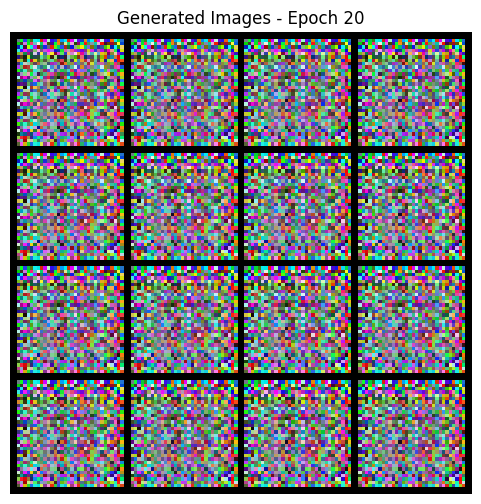

Epoch [21/100]  D_loss: 0.0609  G_loss: 22.4904  Sim_Score: 0.0000
Epoch [22/100]  D_loss: 0.0543  G_loss: 22.4763  Sim_Score: 0.0000
Epoch [23/100]  D_loss: 0.0486  G_loss: 20.5552  Sim_Score: 0.0000
Epoch [24/100]  D_loss: 0.0436  G_loss: 22.3770  Sim_Score: 0.0000
Epoch [25/100]  D_loss: 0.0394  G_loss: 22.3035  Sim_Score: 0.0000
Epoch [26/100]  D_loss: 0.0356  G_loss: 24.6398  Sim_Score: 0.0000
Epoch [27/100]  D_loss: 0.0323  G_loss: 23.4007  Sim_Score: 0.0000
Epoch [28/100]  D_loss: 0.0294  G_loss: 22.8915  Sim_Score: 0.0000
Epoch [29/100]  D_loss: 0.0268  G_loss: 24.2404  Sim_Score: 0.0000
Epoch [30/100]  D_loss: 0.0246  G_loss: 24.7236  Sim_Score: 0.0000


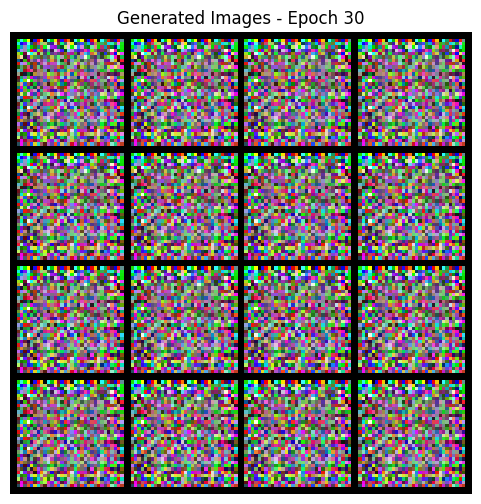

Epoch [31/100]  D_loss: 0.0225  G_loss: 23.9825  Sim_Score: 0.0000
Epoch [32/100]  D_loss: 0.0207  G_loss: 24.3572  Sim_Score: 0.0000
Epoch [33/100]  D_loss: 0.0191  G_loss: 24.2189  Sim_Score: 0.0000
Epoch [34/100]  D_loss: 0.0176  G_loss: 25.0127  Sim_Score: 0.0000
Epoch [35/100]  D_loss: 0.0163  G_loss: 24.2139  Sim_Score: 0.0000
Epoch [36/100]  D_loss: 0.0151  G_loss: 24.6714  Sim_Score: 0.0000
Epoch [37/100]  D_loss: 0.0140  G_loss: 25.5217  Sim_Score: 0.0000
Epoch [38/100]  D_loss: 0.0131  G_loss: 25.6159  Sim_Score: 0.0000
Epoch [39/100]  D_loss: 0.0122  G_loss: 25.3134  Sim_Score: 0.0000
Epoch [40/100]  D_loss: 0.0113  G_loss: 25.2749  Sim_Score: 0.0000


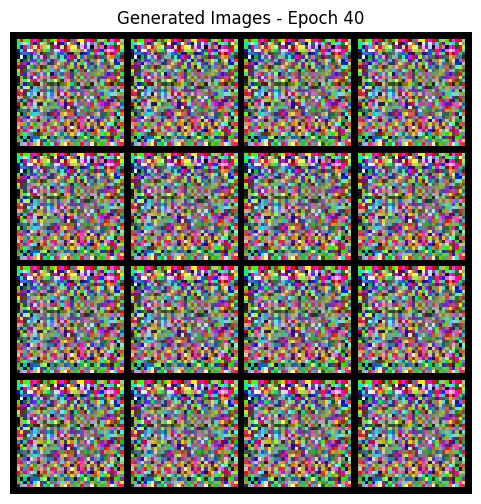

Epoch [41/100]  D_loss: 0.0106  G_loss: 25.6583  Sim_Score: 0.0000
Epoch [42/100]  D_loss: 0.0099  G_loss: 26.2460  Sim_Score: 0.0000
Epoch [43/100]  D_loss: 0.0093  G_loss: 26.1332  Sim_Score: 0.0000
Epoch [44/100]  D_loss: 0.0087  G_loss: 26.5855  Sim_Score: 0.0000
Epoch [45/100]  D_loss: 0.0082  G_loss: 26.5119  Sim_Score: 0.0000
Epoch [46/100]  D_loss: 0.0077  G_loss: 26.1765  Sim_Score: 0.0000
Epoch [47/100]  D_loss: 0.0072  G_loss: 26.2347  Sim_Score: 0.0000
Epoch [48/100]  D_loss: 0.0068  G_loss: 28.7626  Sim_Score: 0.0000
Epoch [49/100]  D_loss: 0.0064  G_loss: 26.1945  Sim_Score: 0.0000
Epoch [50/100]  D_loss: 0.0061  G_loss: 26.5322  Sim_Score: 0.0000


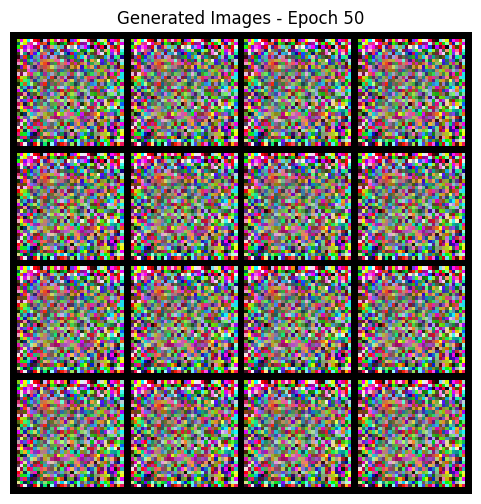

Epoch [51/100]  D_loss: 0.0057  G_loss: 26.0387  Sim_Score: 0.0000
Epoch [52/100]  D_loss: 0.0054  G_loss: 28.3908  Sim_Score: 0.0000
Epoch [53/100]  D_loss: 0.0051  G_loss: 27.9287  Sim_Score: 0.0000
Epoch [54/100]  D_loss: 0.0048  G_loss: 27.8269  Sim_Score: 0.0000
Epoch [55/100]  D_loss: 0.0046  G_loss: 28.5214  Sim_Score: 0.0000
Epoch [56/100]  D_loss: 0.0043  G_loss: 27.5763  Sim_Score: 0.0000
Epoch [57/100]  D_loss: 0.0041  G_loss: 27.6998  Sim_Score: 0.0000
Epoch [58/100]  D_loss: 0.0039  G_loss: 26.7138  Sim_Score: 0.0000
Epoch [59/100]  D_loss: 0.0037  G_loss: 27.6315  Sim_Score: 0.0000
Epoch [60/100]  D_loss: 0.0035  G_loss: 29.2984  Sim_Score: 0.0000


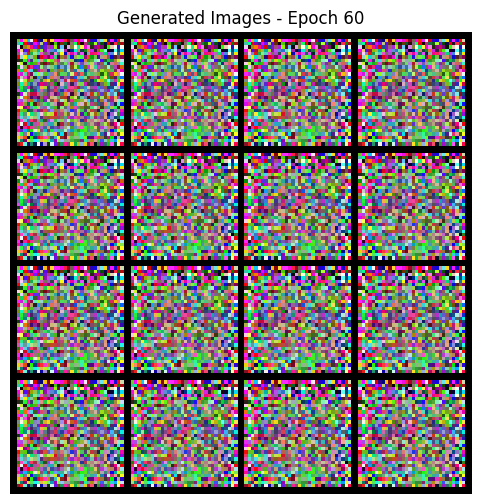

Epoch [61/100]  D_loss: 0.0033  G_loss: 27.3388  Sim_Score: 0.0000
Epoch [62/100]  D_loss: 0.0032  G_loss: 30.0897  Sim_Score: 0.0000
Epoch [63/100]  D_loss: 0.0030  G_loss: 25.8109  Sim_Score: 0.0000
Epoch [64/100]  D_loss: 0.0029  G_loss: 27.5439  Sim_Score: 0.0000
Epoch [65/100]  D_loss: 0.0027  G_loss: 27.7935  Sim_Score: 0.0000
Epoch [66/100]  D_loss: 0.0026  G_loss: 28.8923  Sim_Score: 0.0000
Epoch [67/100]  D_loss: 0.0025  G_loss: 29.9737  Sim_Score: 0.0000
Epoch [68/100]  D_loss: 0.0024  G_loss: 27.8141  Sim_Score: 0.0000
Epoch [69/100]  D_loss: 0.0023  G_loss: 29.0611  Sim_Score: 0.0000
Epoch [70/100]  D_loss: 0.0022  G_loss: 28.2376  Sim_Score: 0.0000


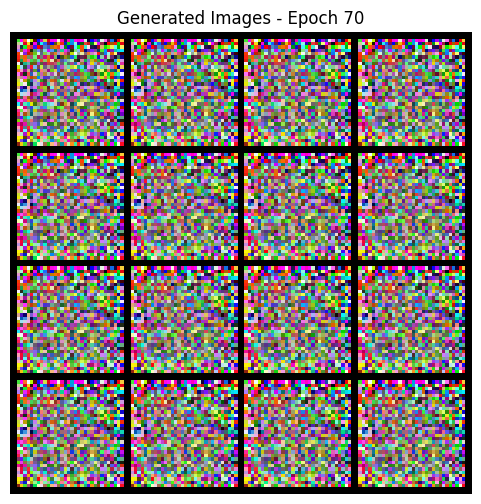

Epoch [71/100]  D_loss: 0.0021  G_loss: 27.5520  Sim_Score: 0.0000
Epoch [72/100]  D_loss: 0.0020  G_loss: 29.6709  Sim_Score: 0.0000
Epoch [73/100]  D_loss: 0.0019  G_loss: 29.3684  Sim_Score: 0.0000
Epoch [74/100]  D_loss: 0.0018  G_loss: 30.0434  Sim_Score: 0.0000
Epoch [75/100]  D_loss: 0.0017  G_loss: 30.2566  Sim_Score: 0.0000
Epoch [76/100]  D_loss: 0.0016  G_loss: 28.8643  Sim_Score: 0.0000
Epoch [77/100]  D_loss: 0.0016  G_loss: 30.5671  Sim_Score: 0.0000
Epoch [78/100]  D_loss: 0.0015  G_loss: 30.3958  Sim_Score: 0.0000
Epoch [79/100]  D_loss: 0.0014  G_loss: 29.4784  Sim_Score: 0.0000
Epoch [80/100]  D_loss: 0.0014  G_loss: 28.4629  Sim_Score: 0.0000


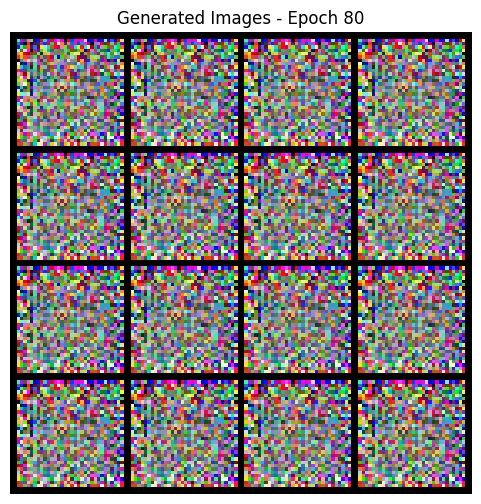

Epoch [81/100]  D_loss: 0.0013  G_loss: 30.2031  Sim_Score: 0.0000
Epoch [82/100]  D_loss: 0.0013  G_loss: 33.0454  Sim_Score: 0.0000
Epoch [83/100]  D_loss: 0.0012  G_loss: 29.0990  Sim_Score: 0.0000
Epoch [84/100]  D_loss: 0.0012  G_loss: 31.4749  Sim_Score: 0.0000
Epoch [85/100]  D_loss: 0.0011  G_loss: 28.5627  Sim_Score: 0.0000
Epoch [86/100]  D_loss: 0.0011  G_loss: 29.5001  Sim_Score: 0.0000
Epoch [87/100]  D_loss: 0.0010  G_loss: 29.5164  Sim_Score: 0.0000
Epoch [88/100]  D_loss: 0.0010  G_loss: 30.9166  Sim_Score: 0.0000
Epoch [89/100]  D_loss: 0.0009  G_loss: 29.7525  Sim_Score: 0.0000
Epoch [90/100]  D_loss: 0.0009  G_loss: 29.1172  Sim_Score: 0.0000


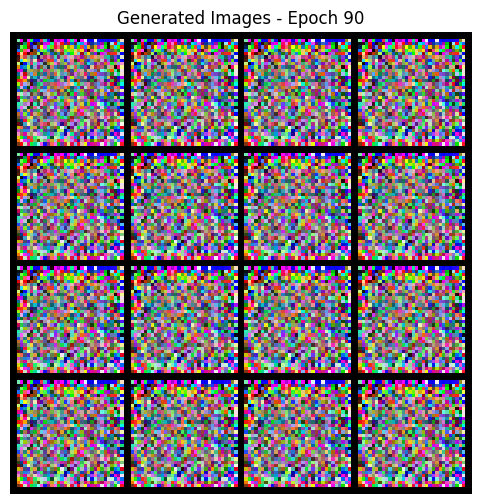

Epoch [91/100]  D_loss: 0.0009  G_loss: 30.6806  Sim_Score: 0.0000
Epoch [92/100]  D_loss: 0.0008  G_loss: 29.6589  Sim_Score: 0.0000
Epoch [93/100]  D_loss: 0.0008  G_loss: 31.9741  Sim_Score: 0.0000
Epoch [94/100]  D_loss: 0.0008  G_loss: 30.7623  Sim_Score: 0.0000
Epoch [95/100]  D_loss: 0.0007  G_loss: 30.5070  Sim_Score: 0.0000
Epoch [96/100]  D_loss: 0.0007  G_loss: 29.1859  Sim_Score: 0.0000
Epoch [97/100]  D_loss: 0.0007  G_loss: 29.5352  Sim_Score: 0.0000
Epoch [98/100]  D_loss: 0.0006  G_loss: 32.3914  Sim_Score: 0.0000
Epoch [99/100]  D_loss: 0.0006  G_loss: 32.5955  Sim_Score: 0.0000
Epoch [100/100]  D_loss: 0.0006  G_loss: 38.8797  Sim_Score: 0.0000


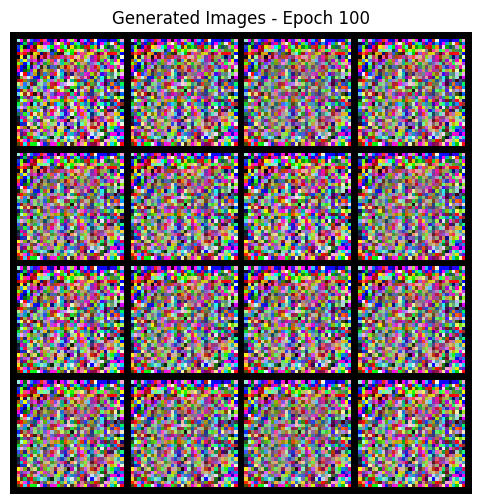

In [12]:
# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 100
image_size = 32
image_channels = 3
batch_size = 128
epochs = 100
lr = 2e-4

# Transforms
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # Normalize to [-1, 1]
])

# Datasets and Loaders
data_path = 'dataset'
train_dataset = ImageFolder(root=os.path.join(data_path, 'train'), transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# 2.1 Generator (DCGAN style)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256*4*4),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, image_channels, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# 2.2 Similarity-based Discriminator using Siamese-style Network
class SimilarityDiscriminator(nn.Module):
    def __init__(self):
        super(SimilarityDiscriminator, self).__init__()
        self.branch = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()  # similarity score
        )

    def forward(self, img1, img2):
        feat1 = self.branch(img1)
        feat2 = self.branch(img2)
        diff = torch.abs(feat1 - feat2)
        sim = self.fc(diff)
        return sim

# 2.3 Loss Functions
criterion = nn.BCELoss()

# Initialize models
G = Generator(latent_dim).to(device)
D = SimilarityDiscriminator().to(device)

# Optimizers
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 2.4 Feature Matching (Diversity promotion)
real_features_mean = None

def get_feature_mean(model, imgs):
    with torch.no_grad():
        feats = model.branch(imgs)
        return feats.mean(dim=0)

# Training loop
G.train()
D.train()
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # ----------------------
        # Train Discriminator
        # ----------------------
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = G(z)

        real_scores = D(real_imgs, real_imgs)  # perfect match => high score
        fake_scores = D(real_imgs, fake_imgs.detach())  # dissimilar => low score

        d_loss_real = criterion(real_scores, torch.ones_like(real_scores))
        d_loss_fake = criterion(fake_scores, torch.zeros_like(fake_scores))
        d_loss = d_loss_real + d_loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ------------------
        # Train Generator
        # ------------------
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = G(z)
        sim_scores = D(real_imgs, fake_imgs)

        g_loss = criterion(sim_scores, torch.ones_like(sim_scores))

        # Feature Matching
        real_mean = get_feature_mean(D, real_imgs)
        fake_mean = get_feature_mean(D, fake_imgs)
        fm_loss = F.mse_loss(fake_mean, real_mean)
        g_loss += fm_loss

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    # Logging
    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}  Sim_Score: {sim_scores.mean().item():.4f}")

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            samples = G(z).cpu()
            grid = make_grid(samples, nrow=4, normalize=True)
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.title(f"Generated Images - Epoch {epoch+1}")
            plt.axis('off')
            plt.show()

# Save models
torch.save(G.state_dict(), 'generator.pth')
torch.save(D.state_dict(), 'discriminator.pth')


**Q1a: GANS**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import random

In [ ]:
# Create directories for saving results
os.makedirs('gan_results', exist_ok=True)
os.makedirs('gan_models', exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hyperparameters 
batch_size = 64
lr_gen = 0.0001  # Reduced learning rate for stability
lr_disc = 0.0004  # Higher disc learning rate to prevent mode collapse
num_epochs = 30  # More epochs for better learning
noise_dim = 128  # Increased noise dimension
image_size = 64  # Increased image size for better details
channels_img = 3  # For CIFAR-10 (RGB images)
save_interval = 5
print_interval = 5  # Print results every 5 epochs
feature_matching_weight = 1.0  # Reduced weight
instance_noise_start = 0.05  # Lower initial instance noise
instance_noise_decay = 0.99  # Slower decay rate
beta1 = 0.5  # Adam optimizer beta1 parameter
one_sided_label_smoothing = 0.9  # Label smoothing for real images

In [ ]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(10), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),  # Color variations
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # Normalize to [-1, 1]
])


train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

cat_dog_indices = [i for i, (_, label) in enumerate(train_dataset) if label in [3, 5]]
train_subset = Subset(train_dataset, cat_dog_indices)

# Create DataLoader with more workers for faster loading
dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4, drop_last=True, pin_memory=True)

# Improved Generator Network with residual connections
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels, in_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        self.relu = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        residual = x
        out = self.block(x)
        out += residual  # Skip connection
        out = self.relu(out)
        return out

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=128, channels_img=3):
        super(Generator, self).__init__()
        
        # Starting size
        self.init_size = 4  
        self.latent_dim = noise_dim
        
        # Initial processing of noise vector
        self.fc = nn.Linear(noise_dim, 512 * self.init_size * self.init_size)
        
        # Main convolutional blocks with residual connections
        self.conv_blocks = nn.Sequential(

            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # First upsampling block
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            ResidualBlock(256),

            
            # Second upsampling block
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            ResidualBlock(128),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            ResidualBlock(64),
     
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True)
            
            # Final conv to get to proper number of channels
            nn.Conv2d(32, channels_img, 3, 1, 1),
            nn.Tanh()  # Output range: [-1, 1]
          
        )
        
    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.size(0), 512, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img


In [ ]:
# Improved Discriminator with self-attention
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)
        
    def forward(self, x):
        batch_size, C, width, height = x.size()
        
        # Reshape for attention calculation
        proj_query = self.query(x).view(batch_size, -1, width * height).permute(0, 2, 1)  
        proj_key = self.key(x).view(batch_size, -1, width * height)  
        
        # Calculate attention map
        energy = torch.bmm(proj_query, proj_key)  
        attention = self.softmax(energy) 
        
        # Apply attention to values
        proj_value = self.value(x).view(batch_size, -1, width * height)  
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))  
        out = out.view(batch_size, C, width, height) 
    
        out = self.gamma * out + x
        return out

class Discriminator(nn.Module):
    def __init__(self, channels_img=3, feature_dim=512):
        super(Discriminator, self).__init__()
        self.feature_dim = feature_dim
        
        self.feature_extractor = nn.Sequential(
            # Input: (channels_img x 64 x 64)
            nn.utils.spectral_norm(nn.Conv2d(channels_img, 64, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),  
            # State Size: (64 x 32 x 32)
            
            nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State Size: (128 x 16 x 16)
            SelfAttention(128),  
            
            nn.utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State Size: (256 x 8 x 8)
            
            nn.utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # State Size: (512 x 4 x 4)
        )
        
        self.classifier = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(512, 1, 4, 1, 0)),
            nn.Sigmoid()
            # Output size: 1x1x1
        )
        
    def forward(self, x):
        # Extract features
        features = self.feature_extractor(x)
        out = self.classifier(features)
        out = out.view(out.size(0), -1)
        return out, features


In [ ]:
# Initialize networks
generator = Generator(noise_dim, channels_img).to(device)
discriminator = Discriminator(channels_img).to(device)


optimizer_G = optim.Adam(generator.parameters(), lr=lr_gen, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_disc, betas=(beta1, 0.999))

# Add weight clipping for Wasserstein-like stability 
def clip_weights(model, clip_value=0.01):
    for p in model.parameters():
        p.data.clamp_(-clip_value, clip_value)


def add_instance_noise(images, noise_level):
    if noise_level > 0:
        noise = torch.randn_like(images) * noise_level
        return images + noise
    return images

# Training loop
print("Starting Improved GAN training...")
print("=" * 50)
print(f"Training on {len(train_subset)} cat and dog images")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate generator: {lr_gen}")
print(f"Learning rate discriminator: {lr_disc}")
print(f"Feature matching weight: {feature_matching_weight}")
print(f"Initial instance noise level: {instance_noise_start}")
print(f"Instance noise decay rate: {instance_noise_decay}")
print("=" * 50)

# Lists to store losses
g_losses = []
d_losses = []
real_scores = []
fake_scores = []

# Initialize fixed noise for visualization
fixed_noise = torch.randn(64, noise_dim, device=device)


current_noise = instance_noise_start

adversarial_loss = nn.BCELoss()
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss()

In [ ]:
for epoch in range(num_epochs):

    running_g_loss = 0.0
    running_d_loss = 0.0
    running_real_score = 0.0
    running_fake_score = 0.0
    
    # Progress bar
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))
    
    for i, (real_images, _) in progress_bar:
        # Get batch size
        current_batch_size = real_images.size(0)
        
        # Configure real and fake labels with label smoothing
        real_label = torch.full((current_batch_size, 1), one_sided_label_smoothing, device=device)
        fake_label = torch.full((current_batch_size, 1), 0.0, device=device)
        
        real_images = real_images.to(device)
        
        for _ in range(2):  
            optimizer_D.zero_grad()
            
            # Generate noise for fake images
            z = torch.randn(current_batch_size, noise_dim, device=device)
            fake_images = generator(z).detach() 
            
                                                                                # Add instance noise to both real and fake for smoother gradients
            real_with_noise = add_instance_noise(real_images, current_noise)
            fake_with_noise = add_instance_noise(fake_images, current_noise)
            
            # Get discriminator outputs
            real_validity, real_features = discriminator(real_with_noise)
            fake_validity, fake_features = discriminator(fake_with_noise)
            
            # Calculate losses - standard BCE loss
            d_real_loss = adversarial_loss(real_validity, real_label)
            d_fake_loss = adversarial_loss(fake_validity, fake_label)
            d_loss = (d_real_loss + d_fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()
            
            real_score = real_validity.mean().item()
            fake_score = fake_validity.mean().item()
            
            running_real_score += real_score
            running_fake_score += fake_score
        
        optimizer_G.zero_grad()
        
        # Generate a batch of fake images again (with new parameters)
        z = torch.randn(current_batch_size, noise_dim, device=device)
        fake_images = generator(z)
        
        # Add instance noise
        fake_with_noise = add_instance_noise(fake_images, current_noise) # Instance noise
        
        fake_validity, fake_features = discriminator(fake_with_noise)
        _, real_features = discriminator(real_with_noise)
        
                                                                                       # Main adversarial loss
        g_adv_loss = adversarial_loss(fake_validity, real_label)

        
        # Feature matching loss for better diversity and stability
        g_feature_loss = mse_loss(fake_features.mean(0), real_features.detach().mean(0))                           # loss function, Feature matching
        
        # Perceptual diversity loss 
        if current_batch_size >= 8:                                   # Need enough batch size for meaningful diversity
            # Create random pairs of fake images
            idx1 = torch.randperm(current_batch_size)[:current_batch_size//2]
            idx2 = torch.randperm(current_batch_size)[:current_batch_size//2]
            sample1 = fake_images[idx1]
            sample2 = fake_images[idx2]
            
            # Encourage different samples to be different from each other
            diversity_loss = -l1_loss(sample1, sample2)  # Negative L1 loss to maximize difference
        else:
            diversity_loss = torch.tensor(0.0, device=device)
        
        # Combine losses
        g_loss = g_adv_loss + feature_matching_weight * g_feature_loss + 0.1 * diversity_loss
        
        # Backward and optimize
        g_loss.backward()
        optimizer_G.step()
        
        # Update metrics
        running_g_loss += g_loss.item()
        running_d_loss += d_loss.item()
        
        # Update progress bar
        progress_bar.set_description(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"D Loss: {d_loss.item():.4f}, "
            f"G Loss: {g_loss.item():.4f}, "
            f"R/F: {real_score:.4f}/{fake_score:.4f}"
        )
    
    # Calculate epoch average metrics
    avg_g_loss = running_g_loss / len(dataloader)
    avg_d_loss = running_d_loss / len(dataloader)
    avg_real_score = running_real_score / (len(dataloader) * 2)  # Account for multiple D updates
    avg_fake_score = running_fake_score / (len(dataloader) * 2)
    
    # Store metrics
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)
    real_scores.append(avg_real_score)
    fake_scores.append(avg_fake_score)
    
    current_noise *= instance_noise_decay


    
    if (epoch + 1) % print_interval == 0 or epoch == num_epochs - 1:
        # Print epoch summary
        print(f"\n{'='*30} EPOCH {epoch+1} SUMMARY {'='*30}")
        print(f"Epoch [{epoch+1}/{num_epochs}] completed")
        print(f"Average Generator Loss: {avg_g_loss:.6f}")
        print(f"Average Discriminator Loss: {avg_d_loss:.6f}")
        print(f"Average Real Score: {avg_real_score:.6f}")
        print(f"Average Fake Score: {avg_fake_score:.6f}")
        print(f"Current Instance Noise Level: {current_noise:.6f}")
        
     
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise).detach().cpu()
        generator.train()
        
        grid = torchvision.utils.make_grid(fake_samples, normalize=True, padding=2)        #Visual Quality of Generated Images
        plt.figure(figsize=(15, 15))
        plt.title(f"Generated Samples - Epoch {epoch+1}")
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'gan_results/gan_samples_epoch_{epoch+1}.png')
        plt.close()
        

        real_grid = torchvision.utils.make_grid(real_images[:64].cpu(), normalize=True, padding=2)
        plt.figure(figsize=(15, 15))
        plt.title(f"Real Images - Epoch {epoch+1}")
        plt.imshow(np.transpose(real_grid, (1, 2, 0)))
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'gan_results/real_samples_epoch_{epoch+1}.png')
        plt.close()
        
        print(f"Saved sample images to gan_results/gan_samples_epoch_{epoch+1}.png")
        print(f"{'='*30} END OF EPOCH {epoch+1} {'='*30}\n")
    
    # Save model checkpoints
    if (epoch + 1) % save_interval == 0 or epoch == num_epochs - 1:
        checkpoint_path = f'gan_models/gan_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_g_state_dict': optimizer_G.state_dict(),
            'optimizer_d_state_dict': optimizer_D.state_dict(),
            'g_loss': avg_g_loss,
            'd_loss': avg_d_loss,
        }, checkpoint_path)
        print(f"Model checkpoint saved to {checkpoint_path}")

                                                           # Learning rate decay after half the training
    if epoch == num_epochs // 2
        for param_group in optimizer_G.param_groups:
            param_group['lr'] *= 0.5
        for param_group in optimizer_D.param_groups:
            param_group['lr'] *= 0.5
        print(f"Learning rates halved at epoch {epoch+1}")

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.title('GAN Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(2, 1, 2)
plt.plot(real_scores, label='Real Score')
plt.plot(fake_scores, label='Fake Score')
plt.title('Discriminator Scores')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('gan_results/gan_training_metrics.png')
plt.close()

print(f"Training metrics saved to gan_results/gan_training_metrics.png")


final_model_path = 'gan_models/gan_final.pth'
torch.save({
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'final_g_loss': g_losses[-1],
    'final_d_loss': d_losses[-1],
}, final_model_path)
print(f"Final model saved to {final_model_path}")

# Fixed latent space interpolation function
def latent_space_interpolation(model, start_noise, end_noise, steps=10):
    batch_size = 8
    start_expanded = start_noise.repeat(batch_size, 1)
    end_expanded = end_noise.repeat(batch_size, 1)
    interpolated_images = []
    
    model.eval() 
    with torch.no_grad():
        for alpha in np.linspace(0, 1, steps):
    
            interpolated_noise = (1-alpha) * start_expanded + alpha * end_expanded
            # Generate image
            interpolated_image = model(interpolated_noise)

            interpolated_images.append(interpolated_image[0:1].cpu())
    model.train()
    
    return torch.cat(interpolated_images)

In [10]:
# Generate final samples
print("\nGenerating final sample images...")
generator.eval()
with torch.no_grad():
    final_samples = generator(fixed_noise).detach().cpu()
generator.train()

# Display final samples
grid = torchvision.utils.make_grid(final_samples, normalize=True, padding=2)
plt.figure(figsize=(20, 20))
plt.title("Final Generated Cat and Dog Images")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('gan_results/gan_final_samples.png', dpi=300)
plt.close()
print("Final samples saved to gan_results/gan_final_samples.png")

# Generate interpolation samples
print("\nGenerating latent space interpolation...")
start_noise = torch.randn(1, noise_dim, device=device)
end_noise = torch.randn(1, noise_dim, device=device)
interpolated_samples = latent_space_interpolation(generator, start_noise, end_noise, steps=8)

# Display interpolated samples
grid = torchvision.utils.make_grid(interpolated_samples, nrow=8, normalize=True, padding=2)
plt.figure(figsize=(20, 5))
plt.title("Latent Space Interpolation")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('gan_results/gan_latent_interpolation.png', dpi=300)
plt.close()
print("Latent space interpolation saved to gan_results/gan_latent_interpolation.png")


def generate_multiple_interpolations(model, num_pairs=4, steps=8):

    all_interpolations = []
    
    model.eval()
    for i in range(num_pairs):
        start_noise = torch.randn(1, noise_dim, device=device)
        end_noise = torch.randn(1, noise_dim, device=device)
        
        # Use a larger batch size to avoid BatchNorm issues
        batch_size = 8
        start_expanded = start_noise.repeat(batch_size, 1)
        end_expanded = end_noise.repeat(batch_size, 1)
        
        row_images = []
        with torch.no_grad():
            for alpha in np.linspace(0, 1, steps):
    
                interp_noise = (1-alpha) * start_expanded + alpha * end_expanded
              
                img = model(interp_noise)[0:1].cpu()
                row_images.append(img)
        
 
        all_interpolations.append(torch.cat(row_images))
    model.train()
    
    return torch.cat(all_interpolations)


multi_interp = generate_multiple_interpolations(generator, num_pairs=4, steps=8)
grid = torchvision.utils.make_grid(multi_interp, nrow=8, normalize=True, padding=2)
plt.figure(figsize=(20, 10))
plt.title("Multiple Latent Space Interpolations")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('gan_results/gan_multiple_interpolations.png', dpi=300)
plt.close()
print("Multiple interpolations saved to gan_results/gan_multiple_interpolations.png")


print(f"Total epochs: {num_epochs}")
print(f"Final generator loss: {g_losses[-1]:.6f}")
print(f"Final discriminator loss: {d_losses[-1]:.6f}")
print(f"Final real score: {real_scores[-1]:.6f}")
print(f"Final fake score: {fake_scores[-1]:.6f}")
print("-"*50)
print(f"All results saved to 'gan_results/' directory")
print(f"All models saved to 'gan_models/' directory")

Using device: cuda
Files already downloaded and verified
Starting Improved GAN training...
Training on 10000 cat and dog images
Number of epochs: 30
Batch size: 64
Learning rate generator: 0.0001
Learning rate discriminator: 0.0004
Feature matching weight: 1.0
Initial instance noise level: 0.05
Instance noise decay rate: 0.99


Epoch [1/30] | D Loss: 0.1925, G Loss: 7.1953, R/F: 0.8889/0.0029: 100%|██████████| 156/156 [00:40<00:00,  3.83it/s]
Epoch [2/30] | D Loss: 0.2055, G Loss: 5.1142, R/F: 0.8539/0.0193: 100%|██████████| 156/156 [00:41<00:00,  3.76it/s]
Epoch [3/30] | D Loss: 0.3181, G Loss: 8.3493, R/F: 0.6216/0.0003: 100%|██████████| 156/156 [00:40<00:00,  3.82it/s]
Epoch [4/30] | D Loss: 0.2326, G Loss: 8.7806, R/F: 0.8442/0.0017: 100%|██████████| 156/156 [00:41<00:00,  3.78it/s]
Epoch [5/30] | D Loss: 0.2496, G Loss: 5.5962, R/F: 0.9762/0.0262: 100%|██████████| 156/156 [00:41<00:00,  3.80it/s] 



============================== EPOCH 5 SUMMARY ==============================
Epoch [5/30] completed
Average Generator Loss: 5.274609
Average Discriminator Loss: 0.220999
Average Real Score: 0.863311
Average Fake Score: 0.035235
Current Instance Noise Level: 0.047550
Saved sample images to gan_results/gan_samples_epoch_5.png
============================== END OF EPOCH 5 ==============================

Model checkpoint saved to gan_models/gan_epoch_5.pth


Epoch [6/30] | D Loss: 0.2356, G Loss: 4.8260, R/F: 0.9547/0.0815: 100%|██████████| 156/156 [00:40<00:00,  3.81it/s]
Epoch [7/30] | D Loss: 0.1953, G Loss: 5.3335, R/F: 0.9139/0.0332: 100%|██████████| 156/156 [00:41<00:00,  3.80it/s]
Epoch [8/30] | D Loss: 0.2112, G Loss: 5.0628, R/F: 0.7873/0.0082: 100%|██████████| 156/156 [00:41<00:00,  3.80it/s]
Epoch [9/30] | D Loss: 0.2660, G Loss: 6.1606, R/F: 0.6617/0.0021: 100%|██████████| 156/156 [00:43<00:00,  3.56it/s]
Epoch [10/30] | D Loss: 0.1800, G Loss: 4.4036, R/F: 0.8624/0.0050: 100%|██████████| 156/156 [00:42<00:00,  3.65it/s]



============================== EPOCH 10 SUMMARY ==============================
Epoch [10/30] completed
Average Generator Loss: 5.212244
Average Discriminator Loss: 0.212736
Average Real Score: 0.859312
Average Fake Score: 0.040142
Current Instance Noise Level: 0.045219
Saved sample images to gan_results/gan_samples_epoch_10.png
============================== END OF EPOCH 10 ==============================

Model checkpoint saved to gan_models/gan_epoch_10.pth


...


============================== EPOCH 20 SUMMARY ==============================
Epoch [20/30] completed
Average Generator Loss: 4.480531
Average Discriminator Loss: 0.216416
Average Real Score: 0.857458
Average Fake Score: 0.041974
Current Instance Noise Level: 0.040895
Saved sample images to gan_results/gan_samples_epoch_20.png
============================== END OF EPOCH 20 ==============================

Model checkpoint saved to gan_models/gan_epoch_20.pth


Epoch [21/30] | D Loss: 0.2572, G Loss: 4.2097, R/F: 0.9660/0.1140: 100%|██████████| 156/156 [00:43<00:00,  3.59it/s]
Epoch [22/30] | D Loss: 0.3263, G Loss: 4.7248, R/F: 0.5760/0.0043: 100%|██████████| 156/156 [00:43<00:00,  3.63it/s]
Epoch [23/30] | D Loss: 0.1999, G Loss: 4.6573, R/F: 0.9378/0.0227: 100%|██████████| 156/156 [00:43<00:00,  3.59it/s]
Epoch [24/30] | D Loss: 0.1789, G Loss: 5.0676, R/F: 0.8723/0.0077: 100%|██████████| 156/156 [00:43<00:00,  3.59it/s]
Epoch [25/30] | D Loss: 0.1982, G Loss: 3.9486, R/F: 0.8267/0.0150: 100%|██████████| 156/156 [00:43<00:00,  3.61it/s]



============================== EPOCH 25 SUMMARY ==============================
Epoch [25/30] completed
Average Generator Loss: 4.089756
Average Discriminator Loss: 0.224666
Average Real Score: 0.847371
Average Fake Score: 0.052827
Current Instance Noise Level: 0.038891
Saved sample images to gan_results/gan_samples_epoch_25.png
============================== END OF EPOCH 25 ==============================

Model checkpoint saved to gan_models/gan_epoch_25.pth


Epoch [26/30] | D Loss: 0.2551, G Loss: 3.9314, R/F: 0.9555/0.1256: 100%|██████████| 156/156 [00:43<00:00,  3.60it/s]
Epoch [27/30] | D Loss: 0.2030, G Loss: 5.3658, R/F: 0.9483/0.0403: 100%|██████████| 156/156 [00:42<00:00,  3.63it/s]
Epoch [28/30] | D Loss: 0.1932, G Loss: 4.4947, R/F: 0.8520/0.0233: 100%|██████████| 156/156 [00:43<00:00,  3.60it/s]
Epoch [29/30] | D Loss: 0.1882, G Loss: 3.8503, R/F: 0.8373/0.0166: 100%|██████████| 156/156 [00:43<00:00,  3.58it/s]
Epoch [30/30] | D Loss: 0.1837, G Loss: 3.3632, R/F: 0.9051/0.0176: 100%|██████████| 156/156 [00:43<00:00,  3.62it/s]



============================== EPOCH 30 SUMMARY ==============================
Epoch [30/30] completed
Average Generator Loss: 4.340184
Average Discriminator Loss: 0.212993
Average Real Score: 0.855562
Average Fake Score: 0.045085
Current Instance Noise Level: 0.036985
Saved sample images to gan_results/gan_samples_epoch_30.png
============================== END OF EPOCH 30 ==============================

Model checkpoint saved to gan_models/gan_epoch_30.pth
Training metrics saved to gan_results/gan_training_metrics.png
Final model saved to gan_models/gan_final.pth

Generating final sample images...
Final samples saved to gan_results/gan_final_samples.png

Generating latent space interpolation...
Latent space interpolation saved to gan_results/gan_latent_interpolation.png
Multiple interpolations saved to gan_results/gan_multiple_interpolations.png

Improved GAN Training and Evaluation Completed!

FINAL TRAINING SUMMARY:
--------------------------------------------------
Total epochs: 

In [11]:
!zip -r /kaggle/working/gan_results.zip /kaggle/working/gan_results
!zip -r /kaggle/working/gan_models.zip /kaggle/working/gan_models

  adding: kaggle/working/gan_results/ (stored 0%)
  adding: kaggle/working/gan_results/gan_training_metrics.png (deflated 17%)
  adding: kaggle/working/gan_results/gan_samples_epoch_20.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_samples_epoch_10.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_final_samples.png (deflated 16%)
  adding: kaggle/working/gan_results/gan_latent_interpolation.png (deflated 25%)
  adding: kaggle/working/gan_results/real_samples_epoch_20.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_samples_epoch_5.png (deflated 0%)
  adding: kaggle/working/gan_results/real_samples_epoch_5.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_samples_epoch_35.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_samples_epoch_25.png (deflated 0%)
  adding: kaggle/working/gan_results/real_samples_epoch_35.png (deflated 0%)
  adding: kaggle/working/gan_results/gan_samples_epoch_15.png (deflated 0%)
  adding: kaggle/working/gan_resu

**Q1 b: VAEs**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [ ]:
# Create directories for saving results
os.makedirs('results', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
batch_size = 64
lr = 0.0002
num_epochs = 20  
latent_dim = 100  # Same as GAN for comparison
image_size = 32
channels_img = 3  
save_interval = 5  # Save model every 5 epochs
print_interval = 5  

# Load CIFAR-10 dataset (same as GAN)
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]), 
])

# Download CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Filter dataset to only include cats (label 3) and dogs (label 5)
cat_dog_indices = [i for i, (_, label) in enumerate(train_dataset) if label in [3, 5]]
train_subset = Subset(train_dataset, cat_dog_indices)

# Create DataLoader
dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

In [ ]:
# VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            # Input: channels_img x 32 x 32
            nn.Conv2d(channels_img, 32, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1),  # 4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1),  # 2x2
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Calculate feature size for flattening
        self.feature_size = 256 * 2 * 2
        
        # Latent space projections
        self.fc_mu = nn.Linear(self.feature_size, latent_dim)
        self.fc_logvar = nn.Linear(self.feature_size, latent_dim)
        
        # Decoder input
        self.decoder_input = nn.Linear(latent_dim, self.feature_size)
        
        # Decoder
        self.decoder = nn.Sequential(
      
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 4x4
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, channels_img, 4, 2, 1),  # 32x32
            nn.Tanh()  # Output scaled to [-1, 1]
        )
    
    def encode(self, x):
        features = self.encoder(x)
        features = features.view(-1, self.feature_size)
        

        mu = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        # Reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        # Transform from latent space to decoder input shape
        features = self.decoder_input(z)
        features = features.view(-1, 256, 2, 2)
        
        # Decode to image
        return self.decoder(features)
    
    def forward(self, x):
        # Encode
        mu, logvar = self.encode(x)
        
        # Sample in latent space
        z = self.reparameterize(mu, logvar)
        
        # Decode
        recon_x = self.decode(z)
        
        return recon_x, mu, logvar, z

In [ ]:
# Loss function for VAE
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (Mean squared error or Binary cross entropy)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

# Function to generate new samples
def generate_samples(model, num_samples=16, latent_dim=100, device=device):
    # Generate random noise
    z = torch.randn(num_samples, latent_dim).to(device)
    
    # Generate samples
    with torch.no_grad():
        samples = model.decode(z)
    
    return samples
    
# Function to display images
def display_images(images, title=None, nrow=8):
    grid = torchvision.utils.make_grid(images.detach().cpu(), nrow=nrow, normalize=True, padding=2)
    plt.figure(figsize=(12, 12))
    if title:
        plt.title(title)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
# Function to visualize reconstructions and samples
def visualize_vae_results(vae, fixed_noise, dataloader, epoch, device, save_path, display=False):
    with torch.no_grad():
        
        samples = vae.decode(fixed_noise).detach().cpu()
        
        # Also get some reconstructions
        real_batch, _ = next(iter(dataloader))
        real_batch = real_batch[:8].to(device)
        recon_batch, _, _, _ = vae(real_batch)
        
        # Create comparison grid (original vs reconstructed)
        comparison = torch.cat([real_batch.cpu(), recon_batch.detach().cpu()])
        
        # Save reconstructions
        grid_recon = torchvision.utils.make_grid(comparison, nrow=8, normalize=True, padding=2)
        plt.figure(figsize=(15, 6))
        plt.subplot(2, 1, 1)
        plt.title(f"Original (top) vs Reconstructed (bottom) - Epoch {epoch+1}")
        plt.imshow(np.transpose(grid_recon, (1, 2, 0)))
        plt.axis('off')
        
        # Save generated samples
        grid_samples = torchvision.utils.make_grid(samples, normalize=True, padding=2)
        plt.subplot(2, 1, 2)
        plt.title(f"Generated Samples - Epoch {epoch+1}")
        plt.imshow(np.transpose(grid_samples, (1, 2, 0)))
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig(save_path)
        
        if display:
            plt.show()
        plt.close()
        
        return samples, comparison

In [ ]:
# Initialize model and optimizer
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=lr, betas=(0.5, 0.999))

# Lists to track metrics
total_losses = []
recon_losses = []
kl_losses = [] 

# Beta annealing schedule for KL term
def beta_schedule(epoch, start=0.0, end=1.0, warmup_epochs=50):
    if epoch < warmup_epochs:
        return start + (end - start) * epoch / warmup_epochs
    else:
        return end

# Training loop
print("Starting VAE training...")
print("=" * 50)
print(f"Training on {len(train_subset)} cat and dog images")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {lr}")
print(f"Latent dimension: {latent_dim}")
print(f"Print interval: {print_interval} epochs")
print("=" * 50)

# Fixed noise for visualization
fixed_noise = torch.randn(64, latent_dim, device=device)

In [ ]:
for epoch in range(num_epochs):
    # Set current beta value for KL weight
    current_beta = beta_schedule(epoch)
    
    # Progress tracking variables
    running_total_loss = 0.0
    running_recon_loss = 0.0
    running_kl_loss = 0.0
    
    # Progress bar
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))
    
    # Training loop for each batch
    for i, (real_images, _) in progress_bar:
        # Move images to device
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        
        # Forward pass
        optimizer.zero_grad()
        recon_images, mu, logvar, z = vae(real_images)
        
        # Calculate loss
        loss, recon_loss, kl_loss = vae_loss_function(recon_images, real_images, mu, logvar, beta=current_beta)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update metrics
        running_total_loss += loss.item()
        running_recon_loss += recon_loss.item()
        running_kl_loss += kl_loss.item()
        
        # Update progress bar
        progress_bar.set_description(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Loss: {loss.item() / batch_size:.4f}, "
            f"Recon: {recon_loss.item() / batch_size:.4f}, "
            f"KL: {kl_loss.item() / batch_size:.4f}, "
            f"Beta: {current_beta:.4f}"
        )
    
    # Calculate epoch average metrics
    avg_total_loss = running_total_loss / len(train_subset)
    avg_recon_loss = running_recon_loss / len(train_subset)
    avg_kl_loss = running_kl_loss / len(train_subset)
    
    # Store metrics
    total_losses.append(avg_total_loss)
    recon_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    if (epoch + 1) % print_interval == 0 or epoch == num_epochs - 1:
        # Print epoch summary with more details
        print(f"\n{'='*30} EPOCH {epoch+1} SUMMARY {'='*30}")
        print(f"Epoch [{epoch+1}/{num_epochs}] completed")
        print(f"Average Total Loss: {avg_total_loss:.6f}")
        print(f"Average Reconstruction Loss: {avg_recon_loss:.6f}")
        print(f"Average KL Loss: {avg_kl_loss:.6f}")
        print(f"Current Beta: {current_beta:.4f}")
        
        epoch_samples = generate_samples(vae, num_samples=16)
        
       
        with torch.no_grad():
            real_batch, _ = next(iter(dataloader))
            batch_subset = real_batch[:8].to(device)
            epoch_recon, _, _, _ = vae(batch_subset)
            epoch_comparison = torch.cat([batch_subset.cpu(), epoch_recon.detach().cpu()])
        
        # Display the samples
        print(f"\n[Epoch {epoch+1}] Displaying generated samples:")
        display_images(epoch_samples, title=f"Generated Samples - Epoch {epoch+1}")
        
        # Display the reconstructions
        print(f"[Epoch {epoch+1}] Displaying reconstructions:")
        display_images(epoch_comparison, title=f"Original (top) vs Reconstructed (bottom) - Epoch {epoch+1}", nrow=8)
        
        # Generate and save sample images with fixed noise
        save_path = f'results/vae_epoch_{epoch+1}.png'
        samples, comparison = visualize_vae_results(vae, fixed_noise, dataloader, epoch, device, save_path, display=True)
        print(f"\nSaved visualizations to {save_path}")
        
        # Create a more detailed visualization 
        with torch.no_grad():
            
            real_batch, _ = next(iter(dataloader))
            real_batch = real_batch[:16].to(device) 
            recon_batch, _, _, _ = vae(real_batch)
            
            # Create grid with more examples
            comparison = torch.cat([real_batch.cpu(), recon_batch.detach().cpu()])
            
            grid_recon = torchvision.utils.make_grid(comparison, nrow=8, normalize=True, padding=2)
            plt.figure(figsize=(16, 12))
            plt.subplot(2, 1, 1)
            plt.title(f"Detailed View - Original (top) vs Reconstructed (bottom) - Epoch {epoch+1}")
            plt.imshow(np.transpose(grid_recon, (1, 2, 0)))
            plt.axis('off')
            
            # More samples
            more_samples = generate_samples(vae, num_samples=32)
            grid_samples = torchvision.utils.make_grid(more_samples.cpu(), nrow=8, normalize=True, padding=2)
            plt.subplot(2, 1, 2)
            plt.title(f"Detailed View - Generated Samples - Epoch {epoch+1}")
            plt.imshow(np.transpose(grid_samples, (1, 2, 0)))
            plt.axis('off')
            
            plt.tight_layout()
            plt.savefig(f'results/vae_detailed_epoch_{epoch+1}.png')
            
            # Also display the detailed images
            plt.show()
            plt.close()
            
            print(f"Saved and displayed detailed reconstructions and samples for epoch {epoch+1}")
            print(f"File saved to: results/vae_detailed_epoch_{epoch+1}.png")
            print(f"{'='*30} END OF EPOCH {epoch+1} {'='*30}\n")
    
    # Save model checkpoints
    if (epoch + 1) % save_interval == 0 or epoch == num_epochs - 1:
        checkpoint_path = f'saved_models/vae_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': vae.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_total_loss,
            'recon_loss': avg_recon_loss,
            'kl_loss': avg_kl_loss,
        }, checkpoint_path)
        print(f"Model checkpoint saved to {checkpoint_path}")

In [ ]:
# Plot and save training metrics
plt.figure(figsize=(12, 8))

# Plot total loss
plt.subplot(3, 1, 1)
plt.plot(total_losses)
plt.title('Total Loss')
plt.grid(True)

# Plot reconstruction loss
plt.subplot(3, 1, 2)
plt.plot(recon_losses)
plt.title('Reconstruction Loss')
plt.grid(True)

# Plot KL divergence
plt.subplot(3, 1, 3)
plt.plot(kl_losses)
plt.title('KL Divergence')
plt.xlabel('Epoch')
plt.grid(True)

plt.tight_layout()
plt.savefig('results/vae_training_metrics.png')
plt.show()
plt.close()

print(f"Training metrics saved to results/vae_training_metrics.png")

# Save final model
final_model_path = 'saved_models/vae_final.pth'
torch.save({
    'model_state_dict': vae.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'latent_dim': latent_dim,
    'final_loss': total_losses[-1],
    'final_recon_loss': recon_losses[-1],
    'final_kl_loss': kl_losses[-1],
}, final_model_path)
print(f"Final model saved to {final_model_path}")

# Generate and save a final set of samples
print("\nGenerating final sample images...")
final_samples = generate_samples(vae, num_samples=64)
grid = torchvision.utils.make_grid(final_samples.cpu(), nrow=8, normalize=True, padding=2)
plt.figure(figsize=(12, 12))
plt.title("Final Generated Samples")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('results/vae_final_samples.png')
plt.show()
plt.close()
print("Final samples saved to results/vae_final_samples.png")

# Function to interpolate between two latent vectors
def latent_space_interpolation(model, num_samples=10):
    print("Generating latent space interpolation...")
    
    # Generate two random latent vectors
    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)
    
    alphas = torch.linspace(0, 1, num_samples).to(device)
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation
            z = alpha * z1 + (1 - alpha) * z2
            # Generate image
            image = model.decode(z)
            interpolated_images.append(image.cpu())
    
    # Concatenate all images
    interpolated_images = torch.cat(interpolated_images)
    return interpolated_images

Using device: cuda
Files already downloaded and verified
Starting VAE training...
Training on 10000 cat and dog images
Number of epochs: 20
Batch size: 64
Learning rate: 0.0002
Latent dimension: 100
Print interval: 5 epochs


Epoch [1/20] | Loss: 472.2191, Recon: 472.2191, KL: 139.6322, Beta: 0.0000: 100%|██████████| 157/157 [00:02<00:00, 74.48it/s]           
Epoch [2/20] | Loss: 239.2598, Recon: 235.1509, KL: 205.4436, Beta: 0.0200: 100%|██████████| 157/157 [00:02<00:00, 74.77it/s]
Epoch [3/20] | Loss: 178.9050, Recon: 170.5495, KL: 208.8876, Beta: 0.0400: 100%|██████████| 157/157 [00:02<00:00, 75.29it/s]
Epoch [4/20] | Loss: 165.6321, Recon: 153.3037, KL: 205.4729, Beta: 0.0600: 100%|██████████| 157/157 [00:02<00:00, 76.50it/s]
Epoch [5/20] | Loss: 196.4849, Recon: 181.3337, KL: 189.3899, Beta: 0.0800: 100%|██████████| 157/157 [00:02<00:00, 72.20it/s]


============================== EPOCH 5 SUMMARY ==============================
Epoch [5/20] completed
Average Total Loss: 168.981080
Average Reconstruction Loss: 153.715176
Average KL Loss: 190.823807
Current Beta: 0.0800



[Epoch 5] Displaying generated samples:


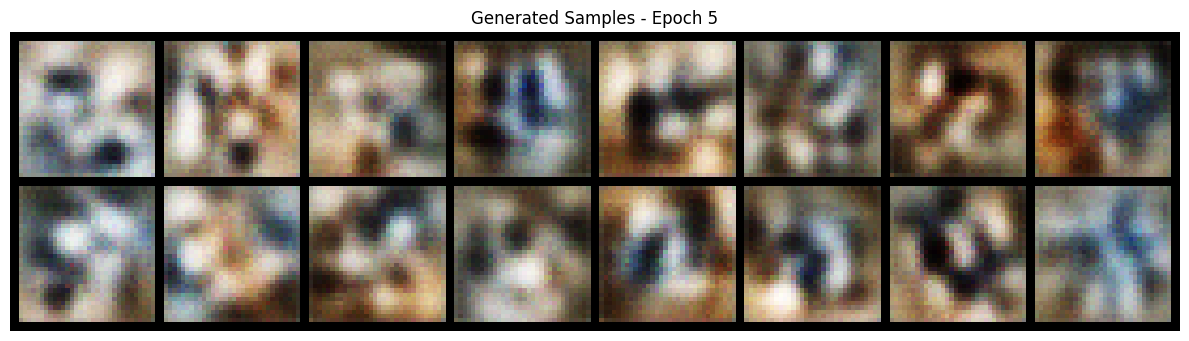

[Epoch 5] Displaying reconstructions:


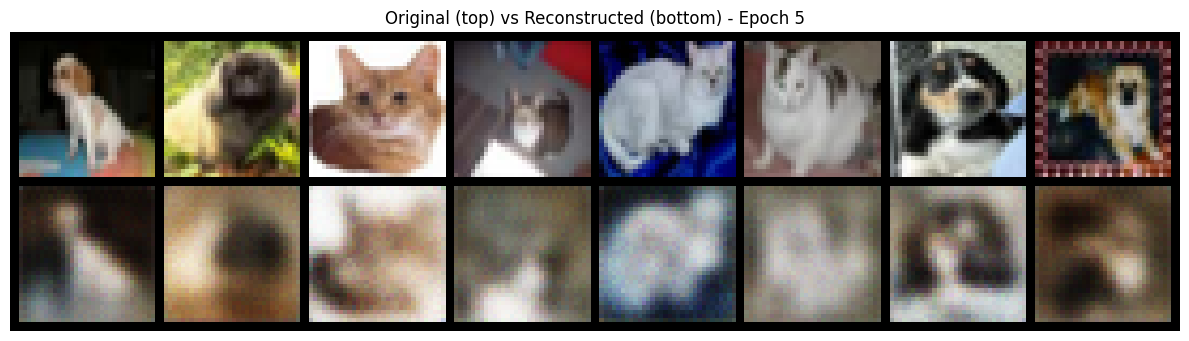

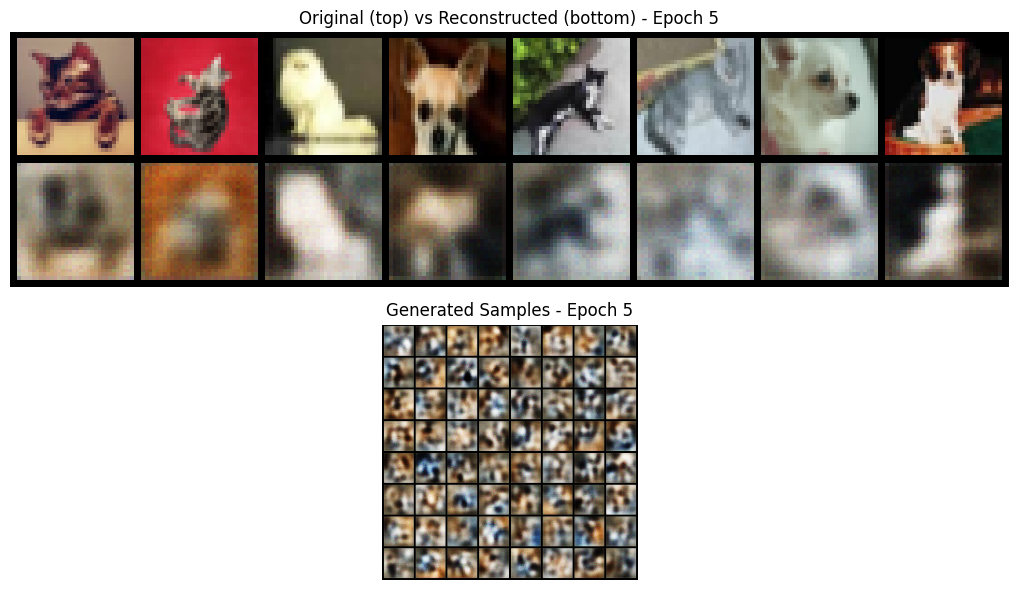


Saved visualizations to results/vae_epoch_5.png


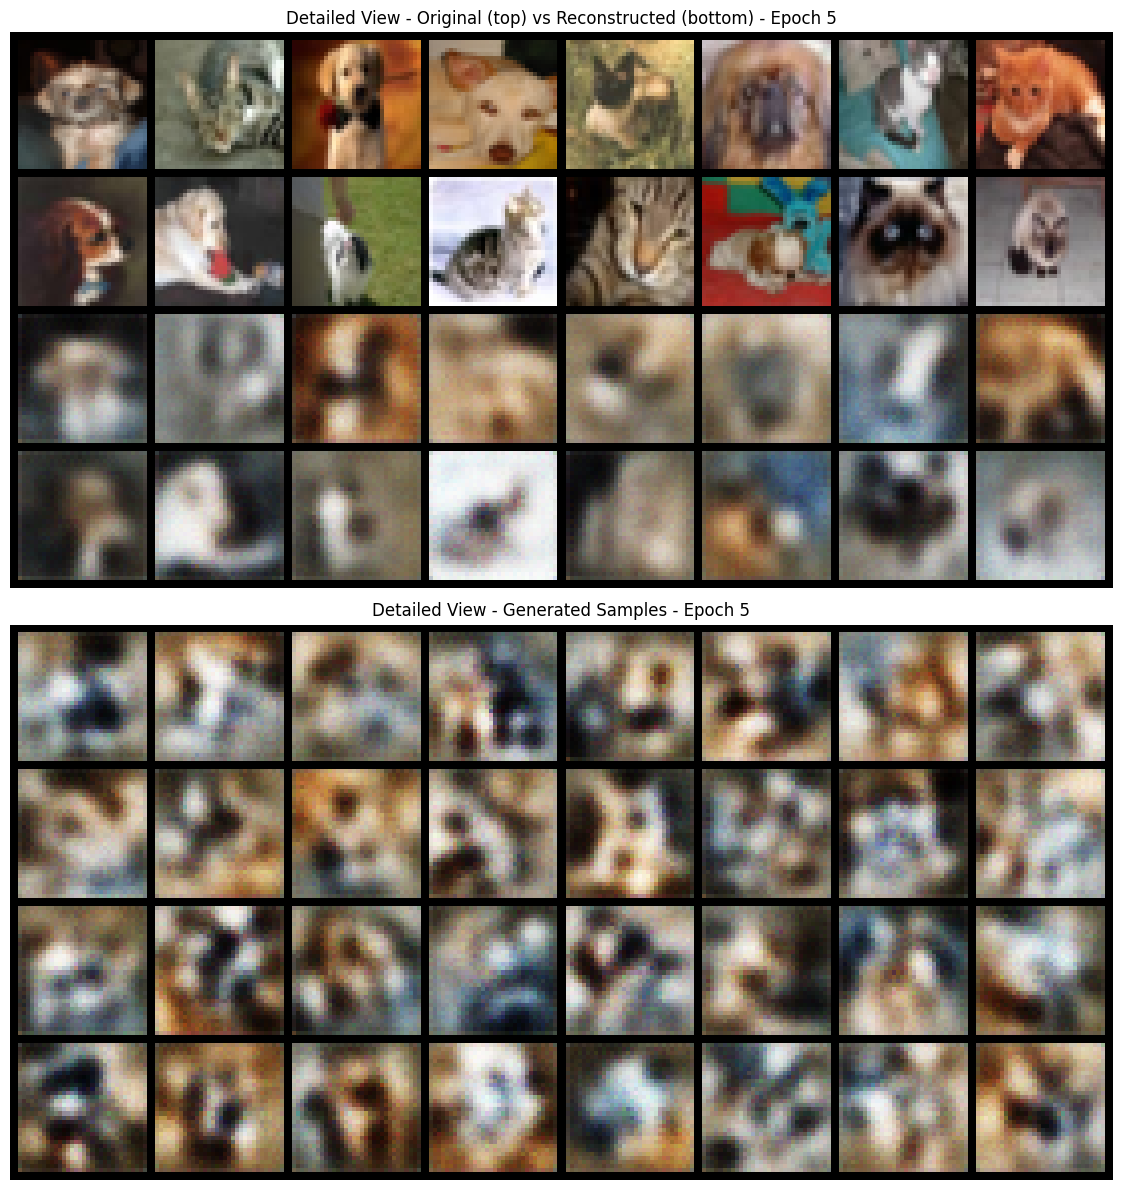

Saved and displayed detailed reconstructions and samples for epoch 5
File saved to: results/vae_detailed_epoch_5.png
============================== END OF EPOCH 5 ==============================

Model checkpoint saved to saved_models/vae_epoch_5.pth


Epoch [6/20] | Loss: 198.3575, Recon: 179.9266, KL: 184.3087, Beta: 0.1000: 100%|██████████| 157/157 [00:01<00:00, 79.13it/s]
Epoch [7/20] | Loss: 173.4252, Recon: 152.6736, KL: 172.9300, Beta: 0.1200: 100%|██████████| 157/157 [00:02<00:00, 77.80it/s]
Epoch [8/20] | Loss: 168.1121, Recon: 144.5101, KL: 168.5856, Beta: 0.1400: 100%|██████████| 157/157 [00:01<00:00, 80.68it/s]
Epoch [9/20] | Loss: 160.3424, Recon: 133.9757, KL: 164.7917, Beta: 0.1600: 100%|██████████| 157/157 [00:02<00:00, 77.97it/s]
Epoch [10/20] | Loss: 181.6938, Recon: 153.3052, KL: 157.7144, Beta: 0.1800: 100%|██████████| 157/157 [00:02<00:00, 77.03it/s]



============================== EPOCH 10 SUMMARY ==============================
Epoch [10/20] completed
Average Total Loss: 152.976589
Average Reconstruction Loss: 124.622476
Average KL Loss: 157.522844
Current Beta: 0.1800

[Epoch 10] Displaying generated samples:


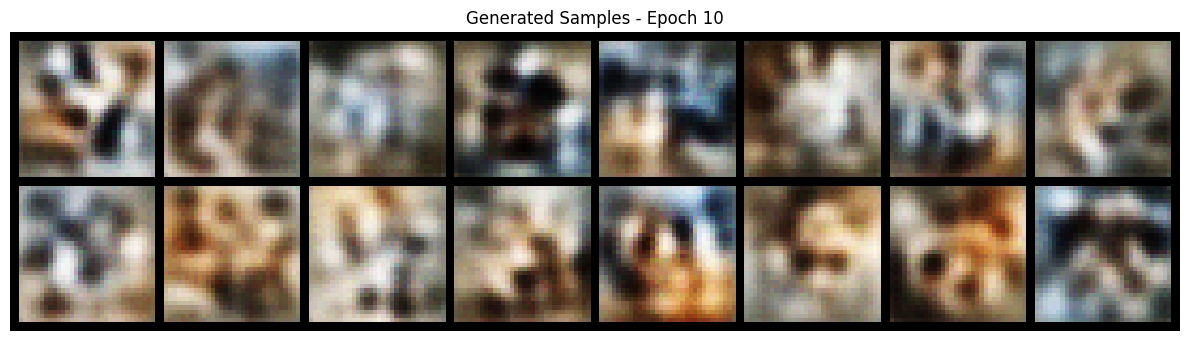

[Epoch 10] Displaying reconstructions:


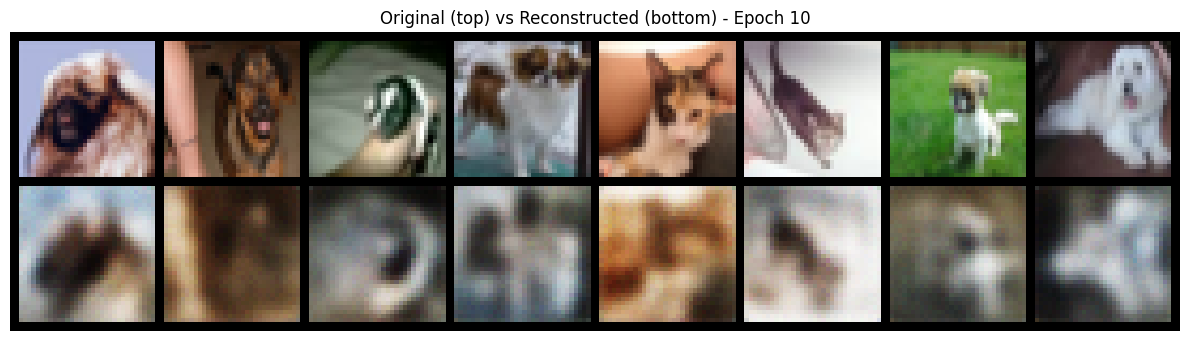

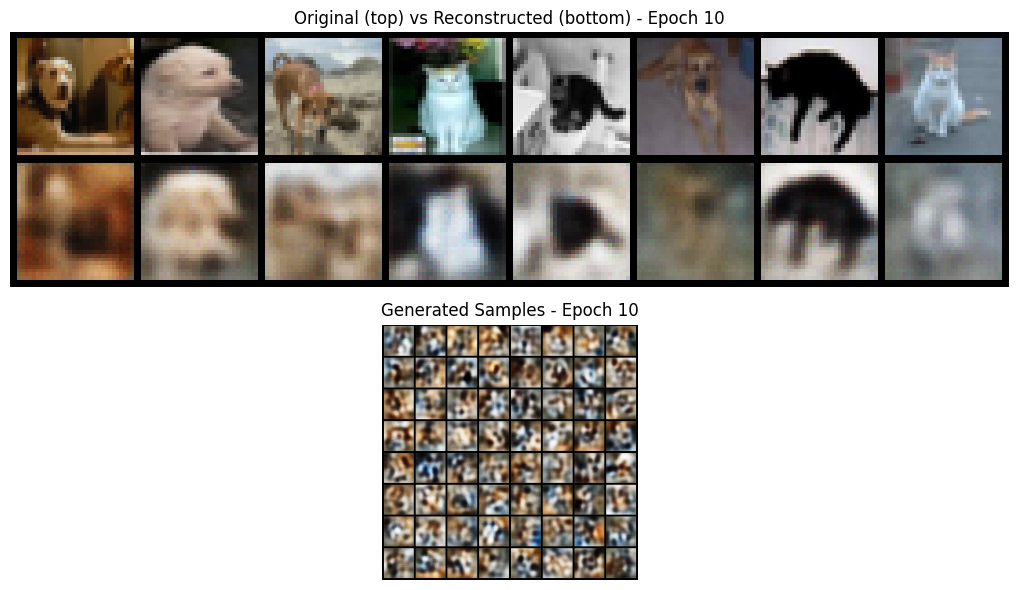


Saved visualizations to results/vae_epoch_10.png


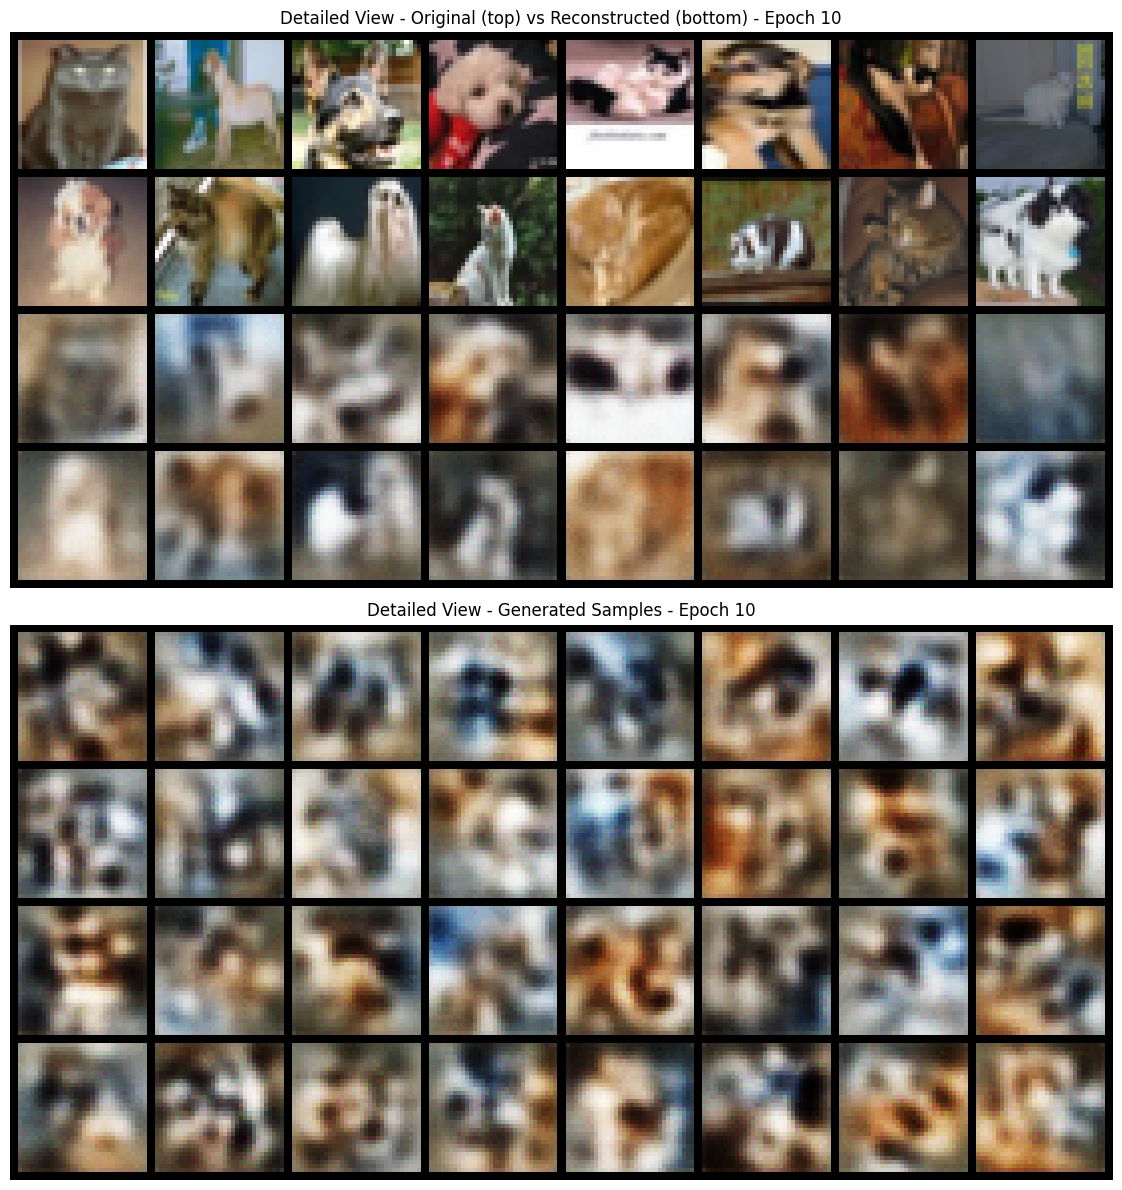

Saved and displayed detailed reconstructions and samples for epoch 10
File saved to: results/vae_detailed_epoch_10.png
============================== END OF EPOCH 10 ==============================

Model checkpoint saved to saved_models/vae_epoch_10.pth


Epoch [11/20] | Loss: 158.7268, Recon: 128.0464, KL: 153.4020, Beta: 0.2000: 100%|██████████| 157/157 [00:02<00:00, 76.85it/s]
Epoch [12/20] | Loss: 157.2538, Recon: 124.6135, KL: 148.3649, Beta: 0.2200: 100%|██████████| 157/157 [00:01<00:00, 80.00it/s]
Epoch [13/20] | Loss: 157.8057, Recon: 123.7248, KL: 142.0037, Beta: 0.2400: 100%|██████████| 157/157 [00:01<00:00, 81.34it/s]
Epoch [14/20] | Loss: 140.2792, Recon: 103.9745, KL: 139.6333, Beta: 0.2600: 100%|██████████| 157/157 [00:02<00:00, 77.04it/s]
Epoch [15/20] | Loss: 173.6054, Recon: 134.8614, KL: 138.3714, Beta: 0.2800: 100%|██████████| 157/157 [00:01<00:00, 79.08it/s]


============================== EPOCH 15 SUMMARY ==============================
Epoch [15/20] completed
Average Total Loss: 154.296960
Average Reconstruction Loss: 116.282523
Average KL Loss: 135.765847
Current Beta: 0.2800



[Epoch 15] Displaying generated samples:


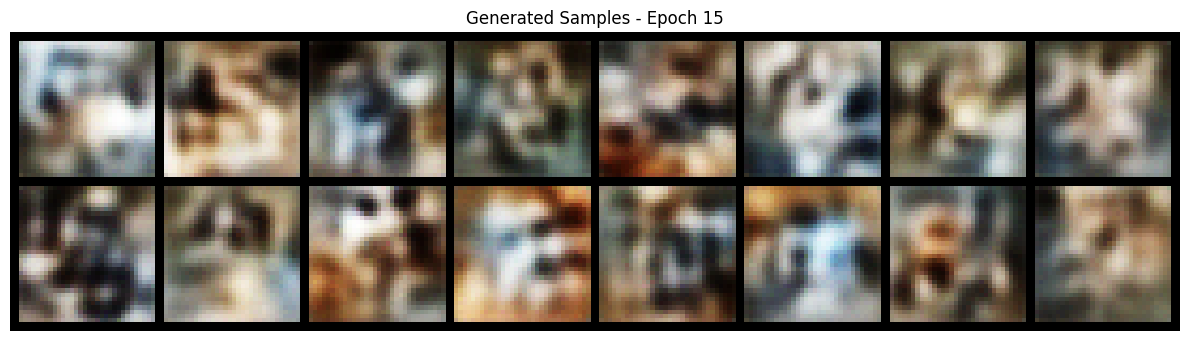

[Epoch 15] Displaying reconstructions:


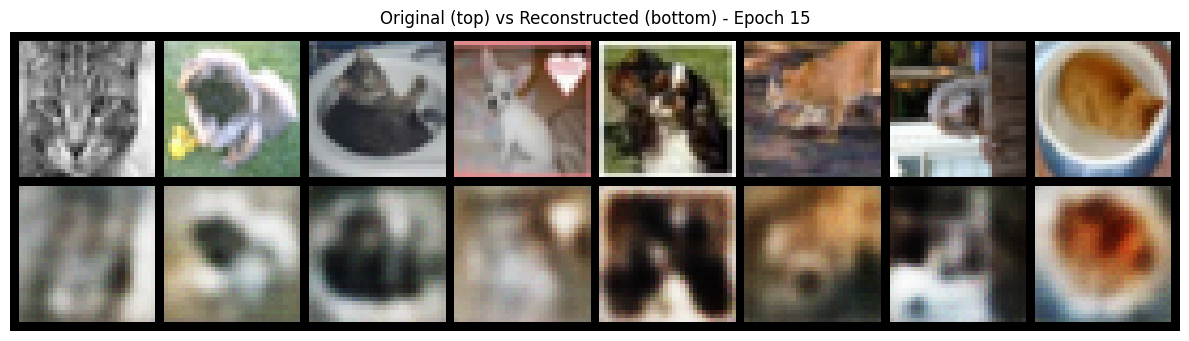

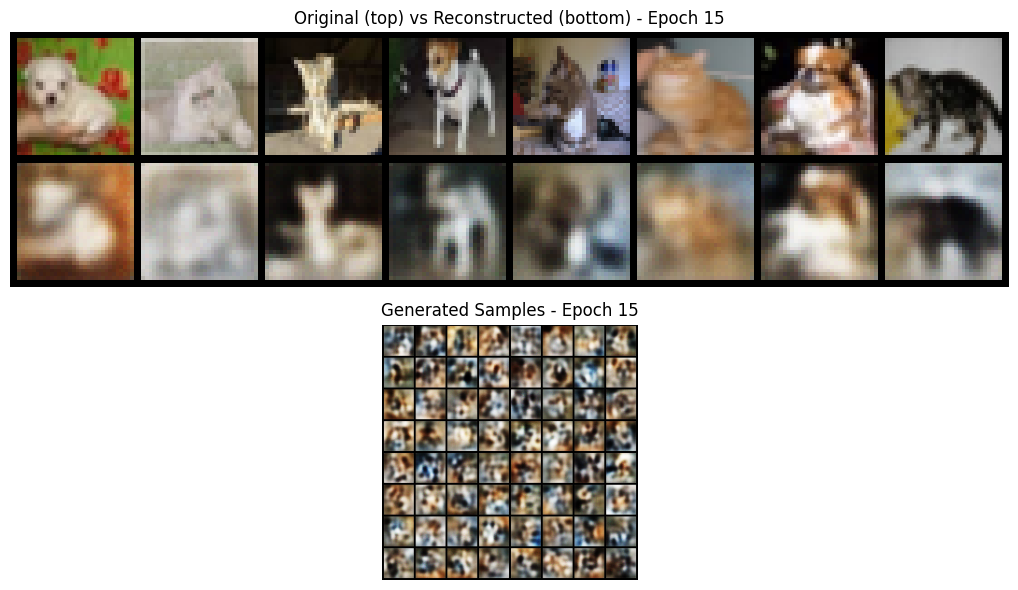


Saved visualizations to results/vae_epoch_15.png


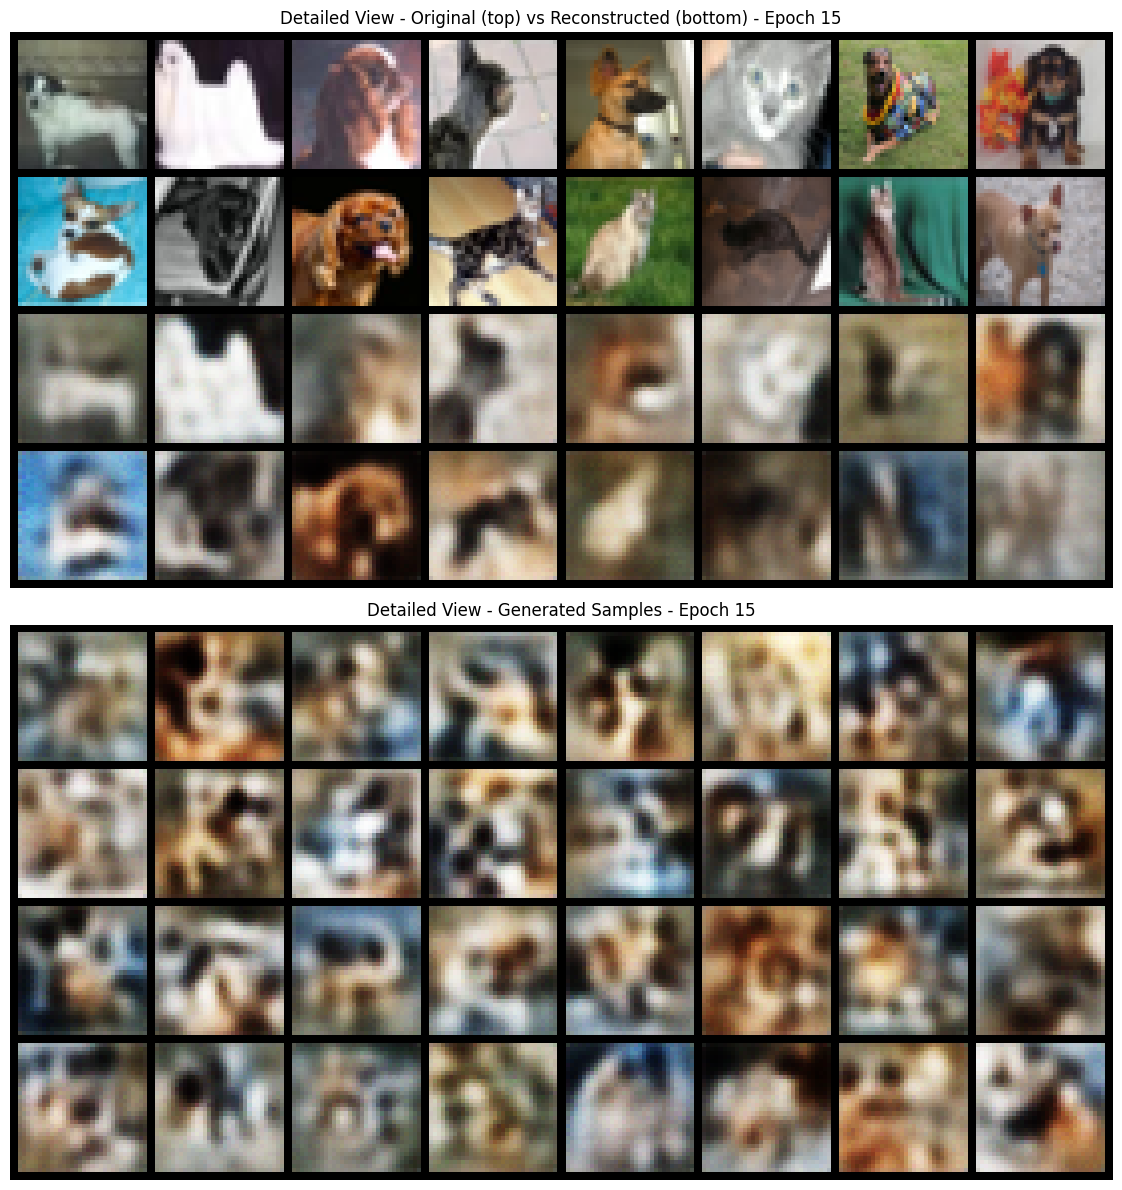

Saved and displayed detailed reconstructions and samples for epoch 15
File saved to: results/vae_detailed_epoch_15.png
============================== END OF EPOCH 15 ==============================

Model checkpoint saved to saved_models/vae_epoch_15.pth


Epoch [16/20] | Loss: 160.1607, Recon: 120.1776, KL: 133.2769, Beta: 0.3000: 100%|██████████| 157/157 [00:02<00:00, 77.05it/s]
Epoch [17/20] | Loss: 145.0493, Recon: 104.7525, KL: 125.9276, Beta: 0.3200: 100%|██████████| 157/157 [00:02<00:00, 77.67it/s]
Epoch [18/20] | Loss: 183.0772, Recon: 140.7549, KL: 124.4773, Beta: 0.3400: 100%|██████████| 157/157 [00:02<00:00, 73.98it/s]
Epoch [19/20] | Loss: 215.0301, Recon: 169.9523, KL: 125.2160, Beta: 0.3600: 100%|██████████| 157/157 [00:02<00:00, 75.69it/s]
Epoch [20/20] | Loss: 157.4509, Recon: 112.3176, KL: 118.7716, Beta: 0.3800: 100%|██████████| 157/157 [00:02<00:00, 77.44it/s]


============================== EPOCH 20 SUMMARY ==============================
Epoch [20/20] completed
Average Total Loss: 157.029491
Average Reconstruction Loss: 111.361989
Average KL Loss: 120.177638
Current Beta: 0.3800



[Epoch 20] Displaying generated samples:


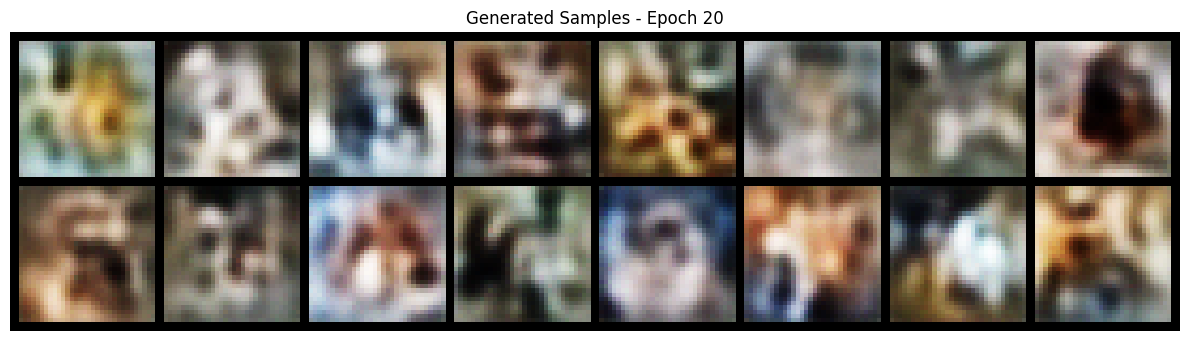

[Epoch 20] Displaying reconstructions:


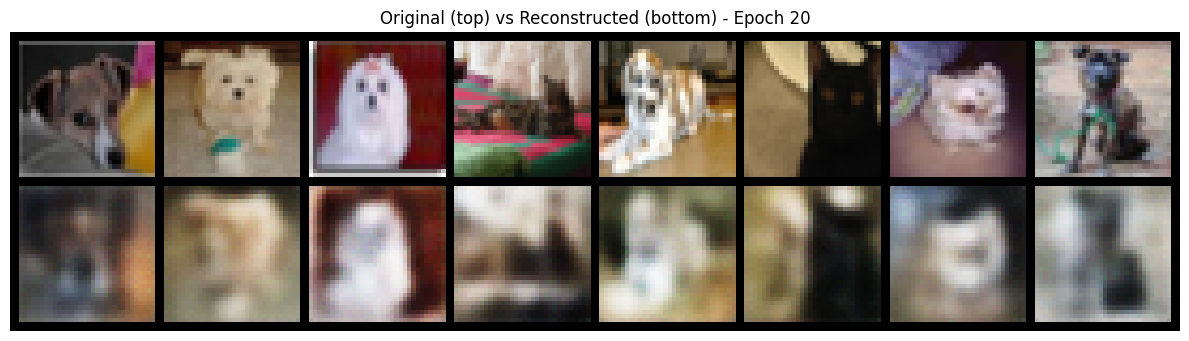

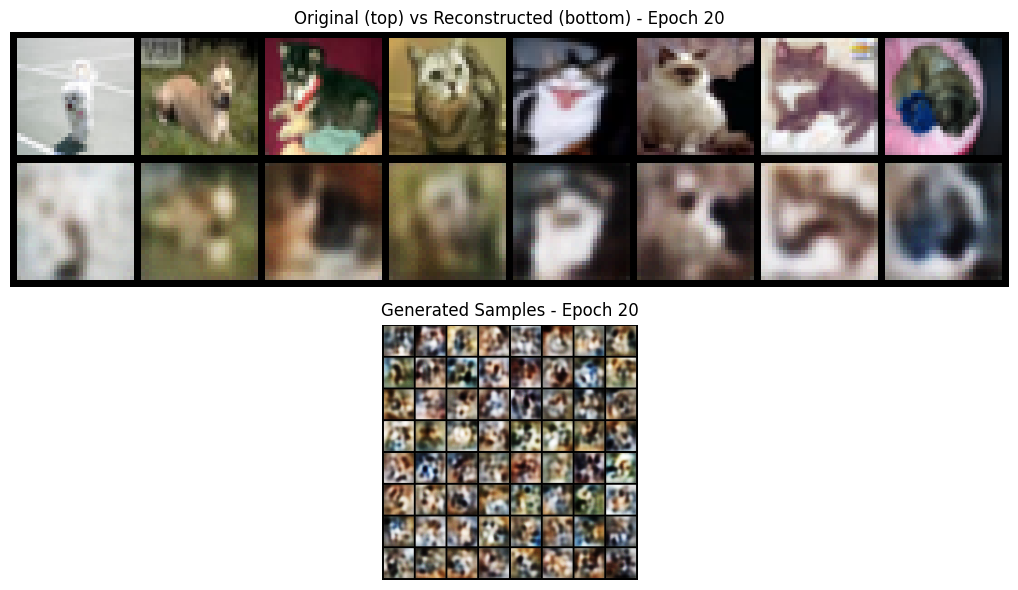


Saved visualizations to results/vae_epoch_20.png


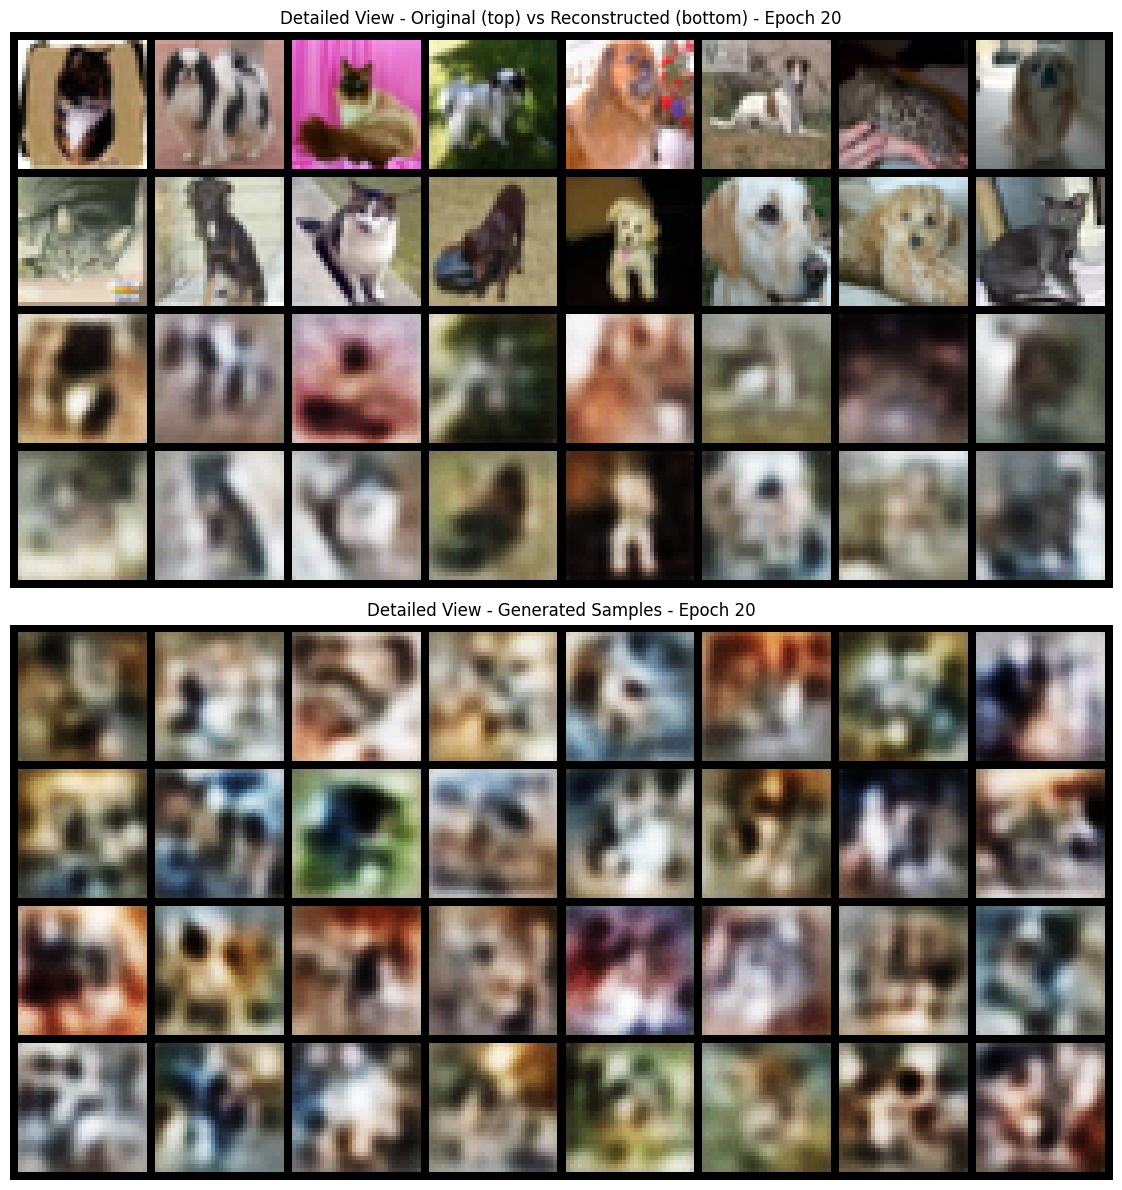

Saved and displayed detailed reconstructions and samples for epoch 20
File saved to: results/vae_detailed_epoch_20.png
============================== END OF EPOCH 20 ==============================

Model checkpoint saved to saved_models/vae_epoch_20.pth


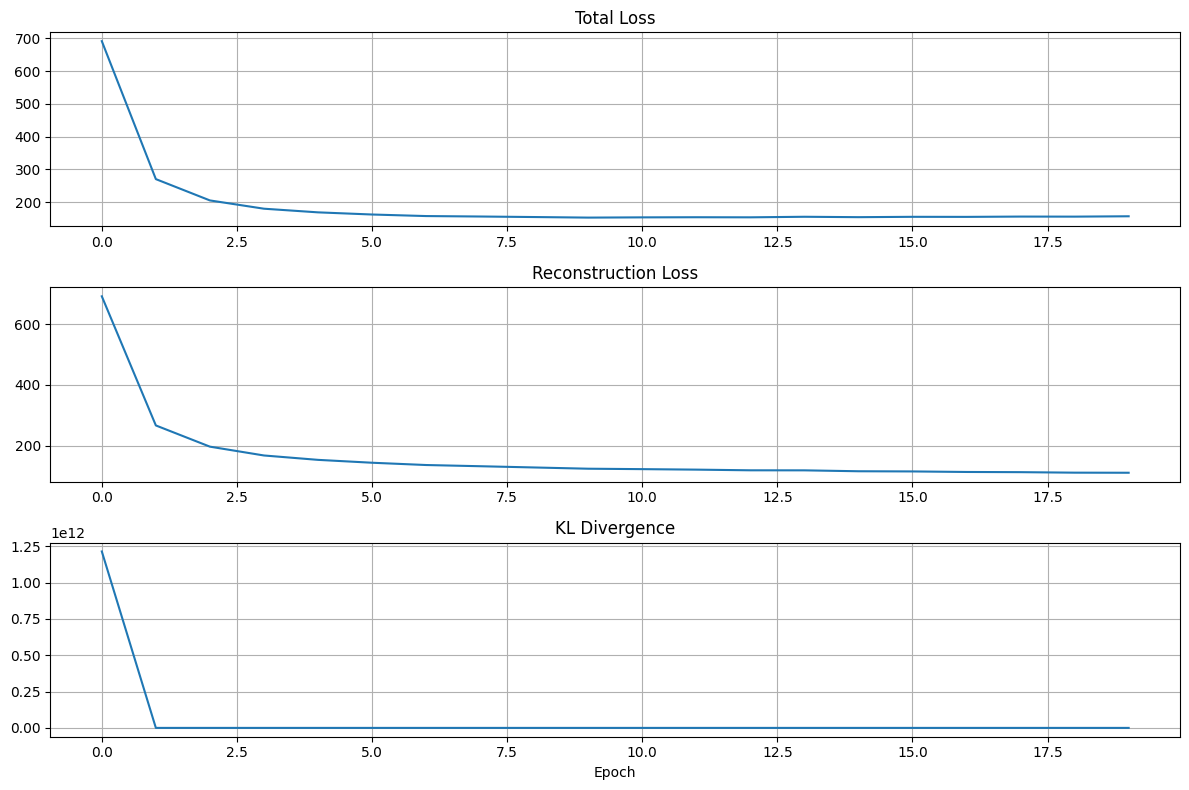

Training metrics saved to results/vae_training_metrics.png
Final model saved to saved_models/vae_final.pth

Generating final sample images...


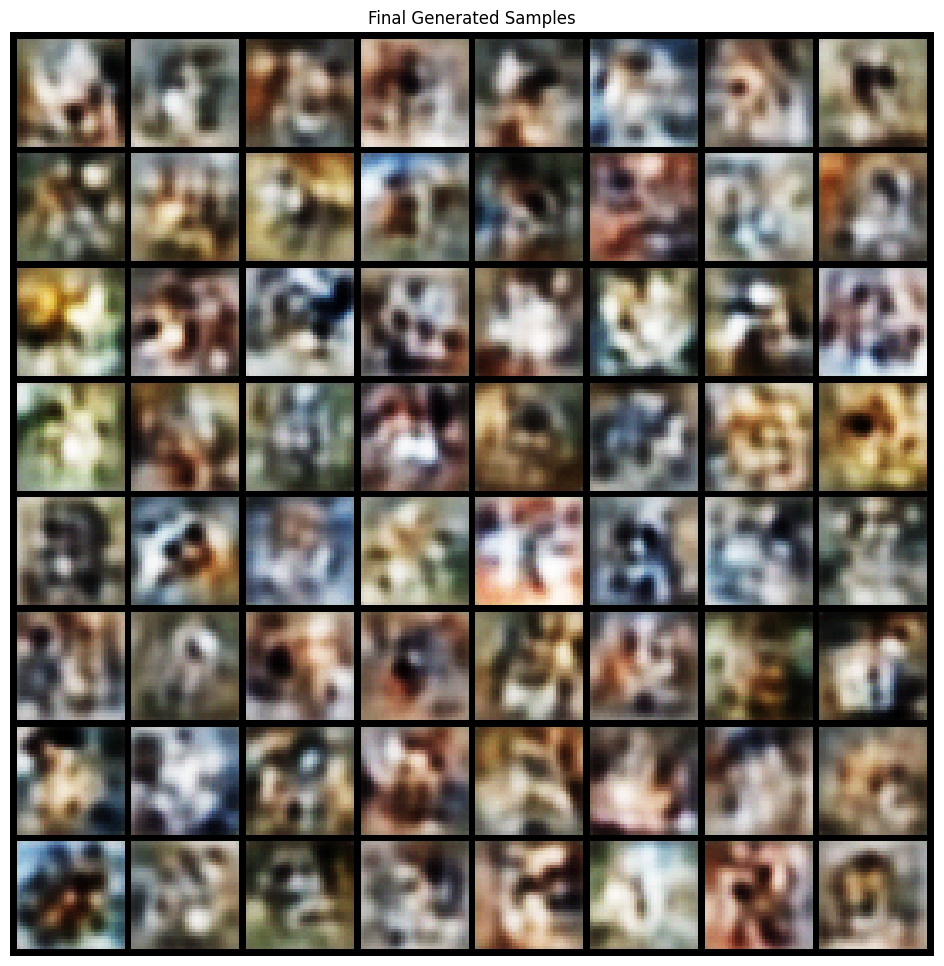

Final samples saved to results/vae_final_samples.png

Generating latent space interpolation...
Generating latent space interpolation...


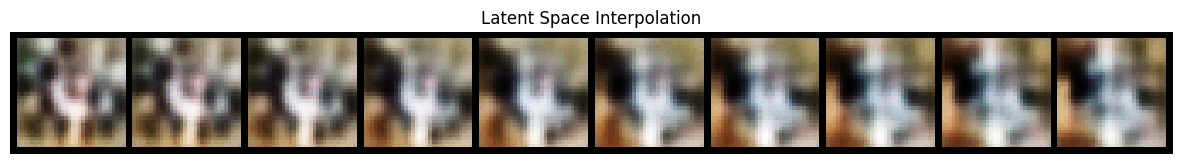

Latent space interpolation saved to results/vae_latent_interpolation.png

pytorch_fid not installed. Install with: pip install pytorch-fid

Calculating reconstruction metrics...


Processing images for metrics:  10%|█         | 16/157 [00:00<00:02, 49.63it/s]


Processed 1000 images for metric calculation

Reconstruction Metrics:
--------------------------------------------------
Average MSE: 0.035546
PSNR: 20.51 dB
Metrics saved to results/vae_metrics.txt

VAE training completed successfully!
Results saved to 'results/' directory
Models saved to 'saved_models/' directory

Testing the decoder with different Gaussian distributions
Generating images with standard Gaussian distribution (mean=0.0, std=1.0)...


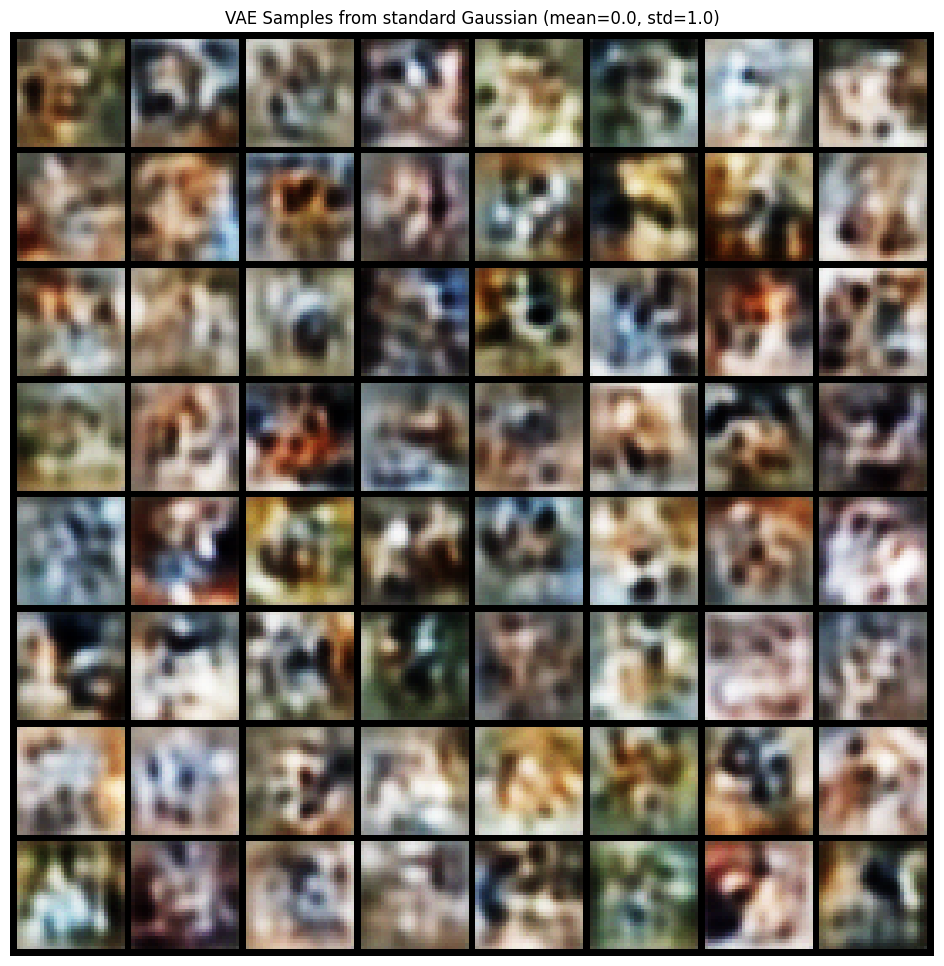

Saved 64 samples from standard Gaussian distribution to results/vae_samples_standard_gaussian.png
Generating images with narrow Gaussian distribution (mean=0.0, std=0.5)...


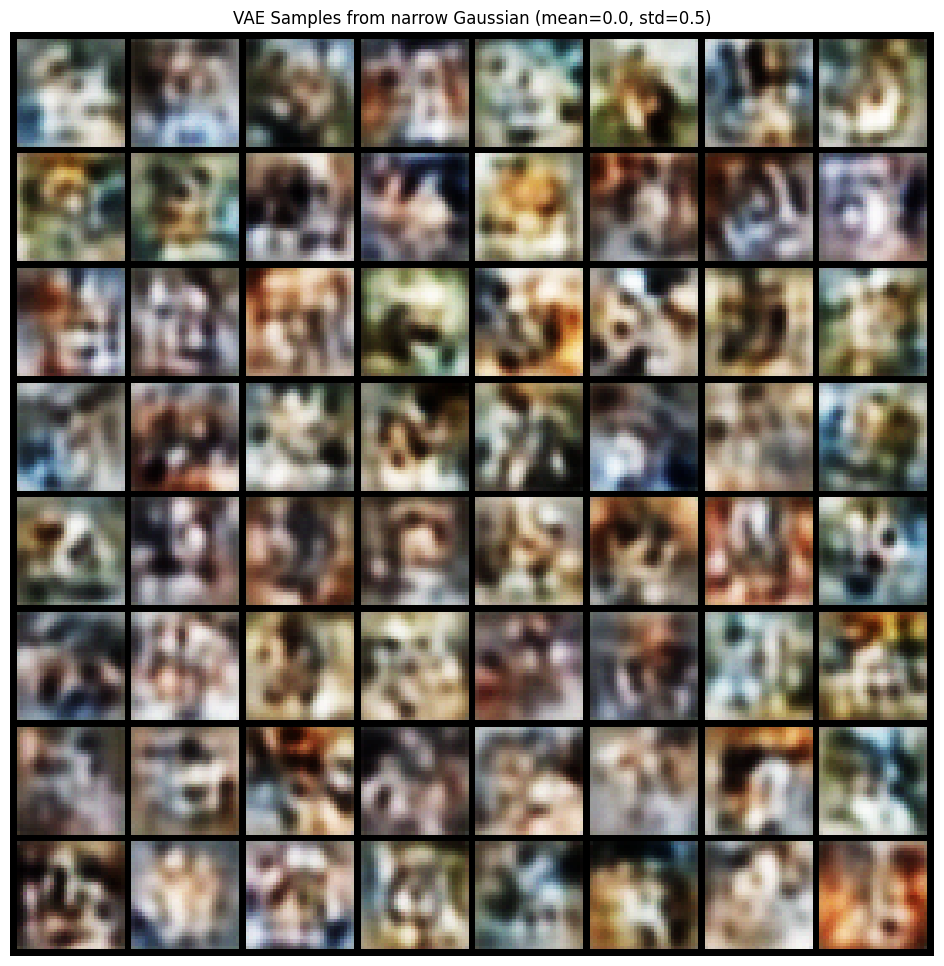

Saved 64 samples from narrow Gaussian distribution to results/vae_samples_narrow_gaussian.png
Generating images with wide Gaussian distribution (mean=0.0, std=2.0)...


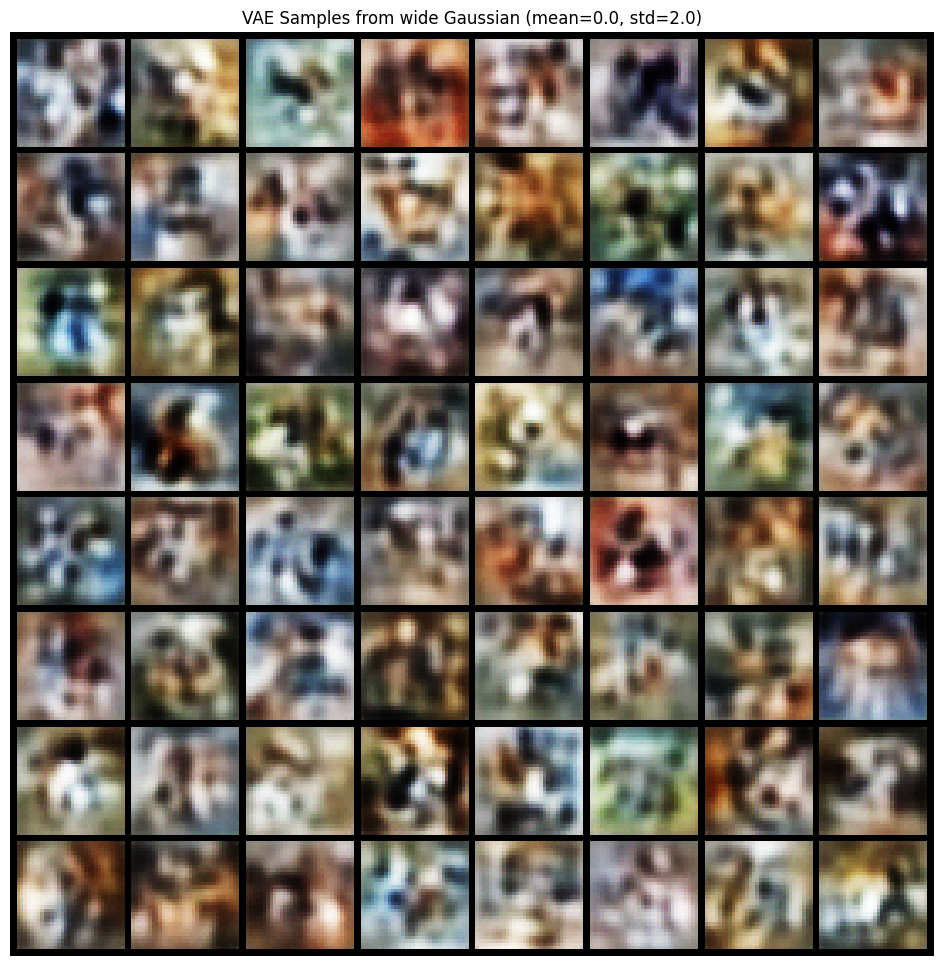

Saved 64 samples from wide Gaussian distribution to results/vae_samples_wide_gaussian.png
Generating images with shifted Gaussian distribution (mean=1.0, std=1.0)...


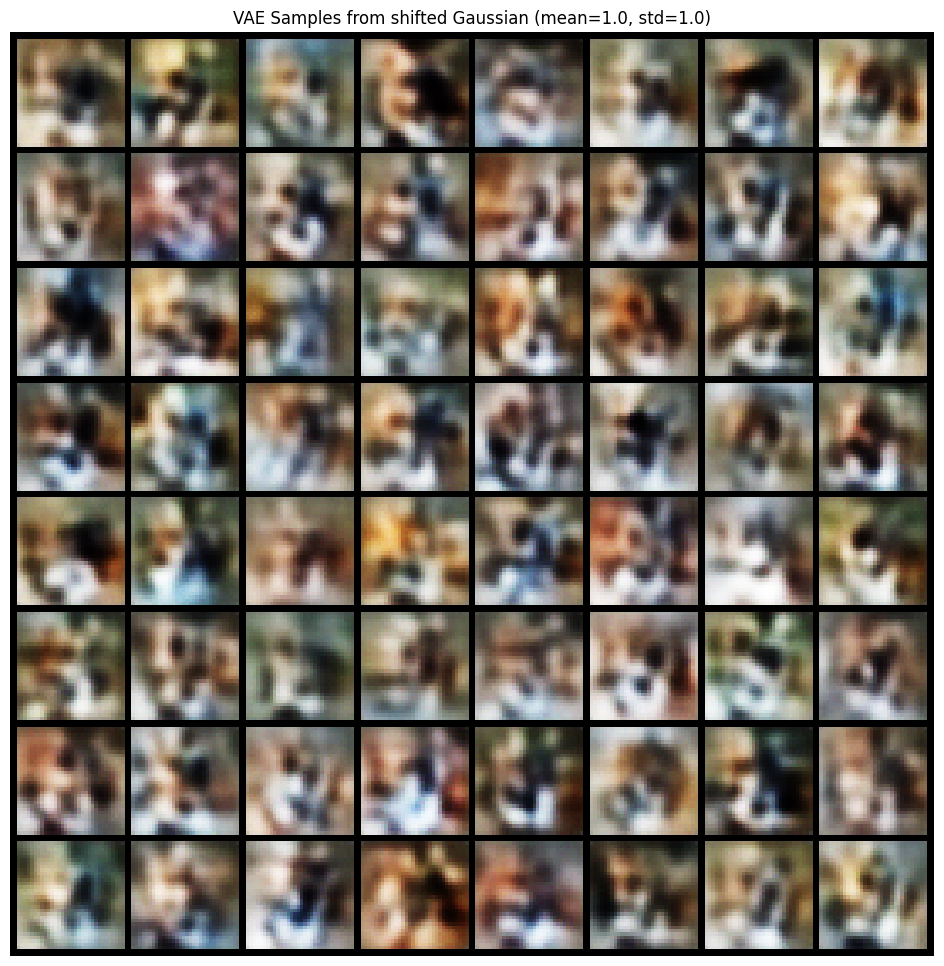

Saved 64 samples from shifted Gaussian distribution to results/vae_samples_shifted_gaussian.png

Generating controlled samples with specific latent dimensions...
Controlled dimensions:
  Dimension 0: 2.0
  Dimension 1: -2.0
  Dimension 2: 0.0


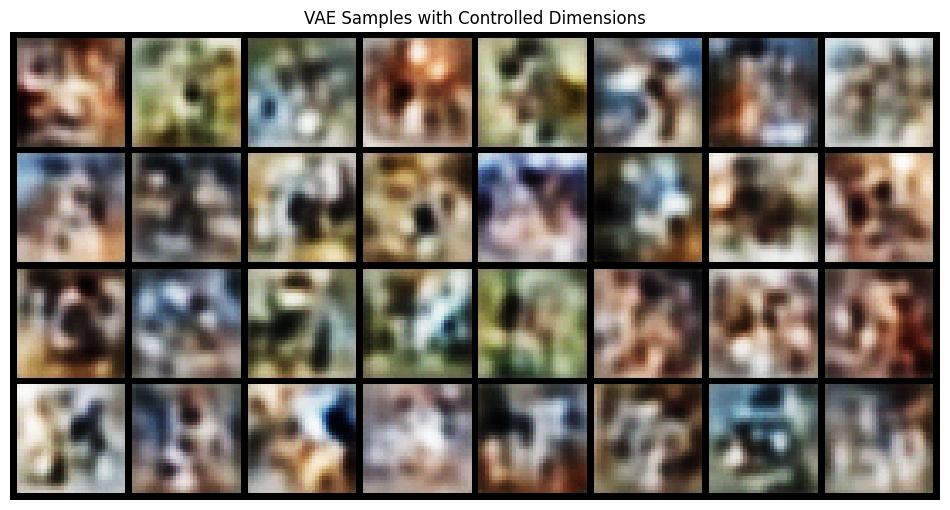

Controlled samples saved to results/vae_controlled_samples.png

Testing completed! All results saved to 'results/' directory

FINAL TRAINING SUMMARY:
--------------------------------------------------
Total epochs: 20
Final total loss: 157.029491
Final reconstruction loss: 111.361989
Final KL loss: 120.177638
Average MSE: 0.035546
PSNR: 20.51 dB
--------------------------------------------------


In [3]:
# Generate and save latent space interpolation
print("\nGenerating latent space interpolation...")
interp_samples = latent_space_interpolation(vae)
grid = torchvision.utils.make_grid(interp_samples, nrow=10, normalize=True, padding=2)
plt.figure(figsize=(15, 4))
plt.title("Latent Space Interpolation")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('results/vae_latent_interpolation.png')
plt.show()
plt.close()
print("Latent space interpolation saved to results/vae_latent_interpolation.png")


try:
    from pytorch_fid import fid_score

    print("\nTo calculate FID score, you'd need reference images and additional setup")
except ImportError:
    print("\npytorch_fid not installed. Install with: pip install pytorch-fid")

# Calculate reconstruction quality metrics
def calculate_reconstruction_metrics(model, dataloader, device, max_samples=1000):
    print("\nCalculating reconstruction metrics...")
    mse_values = []
    samples_processed = 0
    
    with torch.no_grad():
        for images, _ in tqdm(dataloader, desc="Processing images for metrics"):
            if samples_processed >= max_samples:
                break
                
            images = images.to(device)
            recon_images, _, _, _ = model(images)
            
            for i in range(images.size(0)):
                if samples_processed >= max_samples:
                    break
                    
                mse = F.mse_loss(recon_images[i], images[i], reduction='mean').item()
                mse_values.append(mse)
                samples_processed += 1
    
    avg_mse = sum(mse_values) / len(mse_values)
    psnr = 20 * np.log10(2.0) - 10 * np.log10(avg_mse)
    
    print(f"Processed {samples_processed} images for metric calculation")
    return {
        'avg_mse': avg_mse,
        'psnr': psnr  # PSNR calculation (assuming pixel range [-1,1])
    }

# Calculate and print reconstruction metrics
recon_metrics = calculate_reconstruction_metrics(vae, dataloader, device)
print("\n" + "="*50)
print("Reconstruction Metrics:")
print("-"*50)
print(f"Average MSE: {recon_metrics['avg_mse']:.6f}")
print(f"PSNR: {recon_metrics['psnr']:.2f} dB")
print("="*50)

# Save metrics to a file
metrics_file = 'results/vae_metrics.txt'
with open(metrics_file, 'w') as f:
    f.write("VAE Training Summary\n")
    f.write(f"Final Total Loss: {total_losses[-1]:.6f}\n")
    f.write(f"Final Reconstruction Loss: {recon_losses[-1]:.6f}\n")
    f.write(f"Final KL Loss: {kl_losses[-1]:.6f}\n\n")
    f.write(f"Average MSE: {recon_metrics['avg_mse']:.6f}\n")
    f.write(f"PSNR: {recon_metrics['psnr']:.2f} dB\n\n")
    f.write("Training completed successfully!")

print(f"Metrics saved to {metrics_file}")
print("\nVAE training completed successfully!")
print(f"Results saved to 'results/' directory")
print(f"Models saved to 'saved_models/' directory")



def test_decoder_with_distribution(model, mean=0.0, std=1.0, num_samples=64, name="standard"):
    print(f"Generating images with {name} Gaussian distribution (mean={mean}, std={std})...")
    
    # Generate samples from specified distribution
    z = torch.randn(num_samples, latent_dim, device=device) * std + mean
    
    with torch.no_grad():
        samples = model.decode(z).cpu()
    
    # Save samples
    grid = torchvision.utils.make_grid(samples, nrow=8, normalize=True, padding=2)
    plt.figure(figsize=(12, 12))
    plt.title(f"VAE Samples from {name} Gaussian (mean={mean}, std={std})")
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis('off')
    plt.savefig(f'results/vae_samples_{name}_gaussian.png')
    plt.show()
    plt.close()
    
    print(f"Saved {num_samples} samples from {name} Gaussian distribution to results/vae_samples_{name}_gaussian.png")
    return samples

# Generate samples from different distributions
standard_samples = test_decoder_with_distribution(vae, mean=0.0, std=1.0, name="standard")
narrow_samples = test_decoder_with_distribution(vae, mean=0.0, std=0.5, name="narrow")
wide_samples = test_decoder_with_distribution(vae, mean=0.0, std=2.0, name="wide")
shifted_samples = test_decoder_with_distribution(vae, mean=1.0, std=1.0, name="shifted")

# Function to generate controlled samples (trying to guide the generation)
def generate_controlled_samples(model, num_samples=10, dimension_values=None):

    print("\nGenerating controlled samples with specific latent dimensions...")
    if dimension_values is None:
        dimension_values = {}
    
    # Print the controlled dimensions
    print("Controlled dimensions:")
    for dim, value in dimension_values.items():
        print(f"  Dimension {dim}: {value}")
    
    # Create base noise
    z = torch.randn(num_samples, latent_dim, device=device)
    
    # Set specific dimensions to controlled values
    for dim, value in dimension_values.items():
        if dim < latent_dim:
            z[:, dim] = value
    
    # Generate samples
    with torch.no_grad():
        samples = model.decode(z).cpu()
    
    return samples

# Generate and save controlled samples
controlled_dim_values = {
    0: 2.0,  
    1: -2.0, 
    2: 0.0,   
}

controlled_samples = generate_controlled_samples(vae, num_samples=32, dimension_values=controlled_dim_values)
grid = torchvision.utils.make_grid(controlled_samples, nrow=8, normalize=True, padding=2)
plt.figure(figsize=(12, 12))
plt.title("VAE Samples with Controlled Dimensions")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.savefig('results/vae_controlled_samples.png')
plt.show()
plt.close()
print("Controlled samples saved to results/vae_controlled_samples.png")


# Final summary statistics
print("\nFINAL TRAINING SUMMARY:")
print("-"*50)
print(f"Total epochs: {num_epochs}")
print(f"Final total loss: {total_losses[-1]:.6f}")
print(f"Final reconstruction loss: {recon_losses[-1]:.6f}")
print(f"Final KL loss: {kl_losses[-1]:.6f}")
print(f"Average MSE: {recon_metrics['avg_mse']:.6f}")
print(f"PSNR: {recon_metrics['psnr']:.2f} dB")


In [5]:
 !zip -r /kaggle/working/results.zip /kaggle/working/results

  adding: kaggle/working/results/ (stored 0%)
  adding: kaggle/working/results/vae_detailed_epoch_26.png (deflated 7%)
  adding: kaggle/working/results/vae_epoch_36.png (deflated 4%)
  adding: kaggle/working/results/vae_detailed_epoch_6.png (deflated 7%)
  adding: kaggle/working/results/vae_detailed_epoch_39.png (deflated 7%)
  adding: kaggle/working/results/vae_epoch_19.png (deflated 3%)
  adding: kaggle/working/results/vae_epoch_16.png (deflated 3%)
  adding: kaggle/working/results/vae_epoch_27.png (deflated 4%)
  adding: kaggle/working/results/vae_detailed_epoch_13.png (deflated 7%)
  adding: kaggle/working/results/vae_epoch_32.png (deflated 4%)
  adding: kaggle/working/results/vae_epoch_21.png (deflated 3%)
  adding: kaggle/working/results/vae_detailed_epoch_4.png (deflated 7%)
  adding: kaggle/working/results/vae_epoch_14.png (deflated 3%)
  adding: kaggle/working/results/vae_epoch_39.png (deflated 4%)
  adding: kaggle/working/results/vae_metrics.txt (deflated 25%)
  adding: kaggl